<a href="https://colab.research.google.com/github/peterbabulik/QuantumWalker/blob/main/QCA_Genetic_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evolving Quantum Cellular Automata for Computational Tasks: A Search for Novel Algorithms

## Project Overview

This research explores the capabilities of Quantum Cellular Automata (QCA) as a computational paradigm. We leverage evolutionary algorithms (specifically, a Genetic Algorithm - GA) to automatically discover QCA rule sets (including quantum circuit sequences, classical update rules, and initial quantum state preparations) that can perform specific computational tasks. The primary focus of the experiments detailed here is the challenging problem of **integer factorization**.

Our QCA model integrates discrete classical cell states with quantum evolution performed by Qiskit on the underlying qubits. The GA searches the vast parameter space of these QCA configurations to find rules that effectively map computational inputs to desired outputs.

**Keywords:** Quantum Cellular Automata, Evolutionary Algorithms, Genetic Algorithm, Quantum Computation, Integer Factorization, Emergent Computation, Qiskit, Algorithmic Discovery.

---

## A: QCA with Evolutionary Algorithms as a Search Method

### 1. The Quantum Cellular Automaton (QCA) Model

Our QCA model consists of a 1D array of cells (qunodes). Each qunode has:
*   A **classical state** (e.g., TYPE_A representing bit '0', TYPE_B representing bit '1').
*   An underlying **quantum state** (a qubit).

The evolution of the QCA proceeds in discrete steps:

1.  **Initial Quantum State Preparation:** Based on the current classical types of the qunodes and a chosen preparation strategy (e.g., `basis_from_type`, `hadamard_all`, `mixed_A0_BH`), an initial quantum state is prepared for all qubits.
2.  **Quantum Interaction Phase:** A quantum circuit, defined by the `interaction_config` (either as type-based nearest-neighbor rules or an explicit `circuit_sequence` of gates on specific qubits), is applied to the quantum state. This is simulated using Qiskit's `Statevector` simulator.
3.  **Quantum Measurement (Implicit):** We extract the probability P(|1⟩) for each qubit from the final statevector after the quantum interaction.
4.  **Classical Type Update:** The classical state of each qunode is updated based on its P(|1⟩) outcome and a `type_update_rule_config` (e.g., `direct_p1_to_type` thresholding or `simple_threshold` which considers the previous classical state).

### 2. Evolutionary Algorithm (Genetic Algorithm - GA) as the Search Method

To discover QCA rules capable of performing tasks like factorization, we employ a Genetic Algorithm:

*   **Genome/Individual:** Each individual in the GA population represents a complete QCA rule set. In our recent experiments, the genome encodes:
    *   The choice of `initial_quantum_state_prep`.
    *   The choice of `type_update_rule_config` name and its associated parameters (e.g., thresholds).
    *   An `interaction_config`, specifically a `circuit_sequence` which is a list of quantum gate operations (gate type, target qubit(s)) to be applied in order. The maximum length of this circuit is also a parameter of the GA setup.
*   **Fitness Function:** This is crucial for guiding the evolution. For prime factorization of an input `N` into `p` and `q`:
    *   **Primary Reward:** Large positive fitness if `p_pred * q_pred == N` and `p_pred, q_pred > 1`.
    *   **Primality Bonus:** Additional large reward if both `p_pred` and `q_pred` are prime.
    *   **Penalties:**
        *   For incorrect products (`p_pred * q_pred != N`).
        *   For trivial factors (e.g., `1 * N`).
        *   For incorrectly "factoring" a prime input `N` into non-trivial factors.
    *   **Guidance Bonuses:** Small bonuses for finding at least one correct factor even if the other is wrong, or for showing activity in the output registers.
    *   **Diversity Penalty:** A mechanism to slightly penalize solutions that output the same `(p,q)` pair for many different input `N` values.
*   **GA Operators:**
    *   **Initialization:** A population of random genomes is created.
    *   **Selection:** Tournament selection is used to choose parents for the next generation.
    *   **Crossover:** Single-point crossover is applied to parent genomes.
    *   **Mutation:** Each gene in an offspring's genome has a probability of being randomly changed (e.g., selecting a different gate, nudging a threshold, changing a qubit index in the circuit sequence).
    *   **Elitism:** A small number of the best individuals from the current generation are carried over directly to the next.
*   **Evolutionary Loop:** The GA iterates through these steps for a set number of generations, aiming to maximize the fitness score.

---

## B: What We Found With This Method (Key Discoveries for Factorization)

Through several evolutionary runs targeting the factorization of small composite numbers (N up to 15 or 31, with factors up to 7 or 15), our GA-QCA system has made notable discoveries:

1.  **Successful Factorization of Specific Numbers:** The GA has consistently evolved QCA rule sets that can correctly factor specific numbers within the training set into their prime components.
    *   **Example 1 (Fitness ~357):** One evolved rule set (8-gate circuit, `basis_from_type` init, very low `direct_p1_to_type` threshold ~0.038) successfully factored:
        *   `N=10` into `p=2, q=5`.
        *   `N=15` into `p=3, q=5`.
        It also found one correct factor for `N=6` (p=2) and `N=14` (p=2).
    *   **Example 2 (Fitness ~359):** A different 8-gate circuit (different gates, `basis_from_type` init, `direct_p1_to_type` threshold ~0.145) achieved similar overall fitness by:
        *   Factoring `N=10` into `p=5, q=2`.
        *   Factoring `N=14` into `p=7, q=2` (a new success!).
        It regressed on `N=15` but showed the GA explores different solutions.
    *   **Example 3 (Fitness ~350):** Another distinct 8-gate circuit (featuring `RZZ(pi/2)`, two `CCX` gates, and `mixed_A0_BH` init with `direct_p1_to_type` threshold ~0.143) successfully factored:
        *   `N=6` into `p=2, q=3`.
        *   `N=14` into `p=2, q=7`.
        It failed on N=10 and N=15 where previous solutions succeeded.

2.  **Emergence of Non-Trivial Quantum Circuits:** The evolved `circuit_sequence` often contains a mix of:
    *   Single-qubit gates (H, X, S).
    *   Two-qubit entangling gates (CX, CZ, RXX, RYY, RZZ, SWAP).
    *   **Crucially, three-qubit Toffoli gates (CCX)**, which are vital for complex conditional logic.
    The GA is clearly leveraging these quantum resources.

3.  **Co-evolution of Rules:** The GA optimizes the `initial_quantum_state_prep`, the quantum `circuit_sequence`, and the classical `type_update_rule_config` (including its name and thresholds) *simultaneously*. Successful solutions demonstrate a synergy between these components. For instance, very low P(|1⟩) thresholds were sometimes paired with circuits that produced faint but reliable quantum signals.

4.  **Specialization and Local Optima:** The evolved solutions tend to be "specialists" – they perform well on the specific numbers they "learned" during training but show limited generalization to unseen composite numbers or incorrect handling of prime inputs (often attempting to factor them). This is indicative of the GA finding local optima in a very complex fitness landscape.

5.  **"Algorithm" Discovery:** For the specific inputs they solve, these QCA configurations represent deterministic, repeatable processes (algorithms in a specific sense) that achieve factorization through a novel sequence of quantum and classical operations.

---

## C: Why is This Different From Shor's Algorithm?

While both our method and Shor's algorithm address prime factorization using quantum principles, they are fundamentally different:

1.  **Algorithmic Approach:**
    *   **Shor's Algorithm:** A mathematically derived quantum algorithm with specific, well-defined steps:
        1.  Classical pre-processing (checking for trivial factors, evenness).
        2.  Choosing a random number `a < N`.
        3.  Finding the period `r` of `a^x mod N` using the Quantum Fourier Transform (QFT) – this is the core quantum part.
        4.  Classical post-processing to find factors from `r`.
        It relies on number theory and the efficiency of QFT on a quantum computer.
    *   **Evolved QCA:** Our method does not use QFT or modular exponentiation directly. The GA *discovers* a sequence of arbitrary quantum gates from a predefined set. The "logic" for factorization is emergent from the interactions in the evolved circuit and the QCA's update rules. It's a "black-box" discovery approach for a specific QCA architecture.

2.  **Hardware Requirements (Conceptual vs. Actual):**
    *   **Shor's Algorithm:** Requires a fault-tolerant, universal quantum computer with a sufficient number of coherent qubits to achieve its famed (conjectured) exponential speedup over classical algorithms for large numbers.
    *   **Evolved QCA:** Our current work involves *simulating* a QCA model on classical computers. The "quantumness" is in the model of computation being explored. If a highly efficient general QCA factorization rule were found, its practical implementation would depend on the feasibility of building physical QCA hardware that matches the simulated model.

3.  **Generality:**
    *   **Shor's Algorithm:** Is a general algorithm for factoring any composite number `N` (given enough quantum resources).
    *   **Evolved QCA (Current State):** Our findings show specialization. The evolved rules correctly factor specific small numbers they were effectively trained on but do not (yet) generalize to a universal factorization method.

4.  **Discovery Process:**
    *   **Shor's Algorithm:** A product of human ingenuity and mathematical insight into number theory and quantum mechanics.
    *   **Evolved QCA:** The rules are discovered through an automated, heuristic search process (the GA) guided by a fitness function, without prior knowledge of *how* to factor.

In essence, Shor's algorithm is a known, powerful quantum algorithm awaiting capable hardware. Our approach is an exploratory search for *new* computational mechanisms within a specific QCA model, using evolution as the discovery engine. The "algorithms" found by our GA are specific to the QCA paradigm.

---

## D: Potential Usage (Future Usages and Research Directions)

While factoring large numbers suitable for breaking RSA is far beyond the current scope of this simulated QCA approach, this research opens up several interesting avenues:

1.  **Discovering Novel QCA-Specific Algorithms:**
    *   For tasks beyond factorization (e.g., pattern recognition, optimization, simulation of physical systems), this GA-QCA framework could uncover computational strategies uniquely suited to the QCA architecture that are not obvious from classical or standard quantum circuit perspectives.
    *   The analysis of successful evolved circuits can provide insights into new quantum computational primitives.

2.  **Exploring the Computational Power of Restricted Quantum Models:**
    *   QCAs are a particular model of quantum computation, often with constraints like local interactions (though our `circuit_sequence` allows non-local for now). Studying what tasks can be evolved on them helps delineate the boundaries of their computational power.

3.  **Automated Design of Quantum Circuits for Specific Tasks:**
    *   For small, specialized quantum computations, an evolutionary approach might find compact and efficient circuits that are hard for humans to design manually.
    *   This could be relevant for compiling parts of larger quantum algorithms or for near-term quantum devices with limited qubit counts and connectivity.

4.  **Understanding Emergence in Complex Systems:**
    *   The QCA itself is a complex system where local rules lead to global behavior. Studying how evolution shapes these rules to achieve a specific computation provides insights into emergent phenomena.

5.  **Inspiration for New Hardware Architectures:**
    *   If highly efficient QCA rules for certain problems are found, it could inspire the design of physical devices that naturally implement such QCA dynamics.

6.  **Benchmarking Evolutionary Algorithms:**
    *   Using hard computational problems like factorization as benchmarks for GAs that evolve quantum programs can help refine and improve the evolutionary search techniques themselves.

7.  **Hybrid Quantum-Classical Systems:**
    *   Our model inherently has a quantum evolution phase and a classical update/decision phase. Exploring the optimal interplay between these for problem-solving is a rich area. The co-evolution of quantum circuits and classical processing rules (like the P(|1⟩) threshold) is a key aspect.

**Future Research Goals:**

*   **Improving Generalization:** Developing techniques (e.g., more diverse/dynamic training, fitness functions that reward generality) to evolve QCAs that can factor a wider range of numbers.
*   **Scaling:** Investigating methods to scale the problem (more qubits for larger `N`) and the evolutionary search (more efficient GAs, parallelization).
*   **Interpreting Evolved Circuits:** Developing tools and techniques to better understand the "logic" of the quantum circuits discovered by the GA.
*   **Exploring Different QCA Architectures:** Modifying the QCA model (e.g., 2D grids, different neighborhood structures for type-based rules, different underlying quantum gate sets).

This research is at the intersection of quantum computation, artificial life, and machine learning, offering a unique path to explore the computational capabilities of quantum-inspired systems.

---

In [1]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 5.4 MB/s eta 0:00:00


V1 50 runs
Please run this first!

In [2]:

import numpy as np
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import CXGate, CZGate, RZZGate, RXXGate, RYYGate, SwapGate, HGate, XGate, IGate, SGate, TGate, CCXGate
import matplotlib.pyplot as plt
import time
import os
import json # For saving/loading rules
from typing import List, Optional, Tuple, Dict, Any
from tqdm import tqdm
import math
import random

# --- QCA Parameters ---
TYPE_A = 0
TYPE_B = 1

# --- QCA Class and Fitness Function (Ensure these are your latest working versions) ---
# [YOUR QuantumCellularAutomaton CLASS DEFINITION GOES HERE]
# [YOUR is_prime_simple FUNCTION GOES HERE]
# [YOUR calculate_factorization_fitness FUNCTION GOES HERE]

# --- [PASTE QuantumCellularAutomaton class here] ---
GATES = { # Global GATES dictionary
    "H": HGate(), "X": XGate(), "I": IGate(), "S": SGate(), "T": TGate(),
    "CX": CXGate(), "CZ": CZGate(), "SWAP": SwapGate(), "CCX": CCXGate(),
    "RZZ_PIO4": RZZGate(np.pi/4), "RZZ_PIO2": RZZGate(np.pi/2),
    "RXX_PIO4": RXXGate(np.pi/4), "RYY_PIO4": RYYGate(np.pi/4),
}
class QuantumCellularAutomaton:
    def __init__(self, num_qunodes: int, initial_types: np.ndarray,
                 interaction_config: Dict,
                 type_update_rule_config: Dict,
                 initial_quantum_state_prep: str = "all_zero"
                ):
        self.num_qunodes = num_qunodes
        if len(initial_types) != num_qunodes: raise ValueError("initial_types length mismatch.")
        self.current_types = initial_types.copy()
        self.type_history = [self.current_types.copy()]
        self.quantum_outcome_history = []
        self.interaction_config = interaction_config
        self.type_update_rule_config = type_update_rule_config
        self.initial_quantum_state_prep = initial_quantum_state_prep
        self.simulator = AerSimulator(method='statevector')
        self.circuit_visualization_list = [] # Only store first for brevity

    def _get_gate_object(self, gate_name_or_obj):
        if isinstance(gate_name_or_obj, str):
            return GATES.get(gate_name_or_obj.upper(), GATES["I"])
        elif isinstance(gate_name_or_obj, qiskit.circuit.Instruction):
            return gate_name_or_obj
        return GATES["I"]

    def _build_interaction_circuit(self) -> QuantumCircuit:
        qc_step = QuantumCircuit(self.num_qunodes, name=f"QCA_Interaction_Step")
        if self.initial_quantum_state_prep == "hadamard_all": [qc_step.h(i) for i in range(self.num_qunodes)]
        elif self.initial_quantum_state_prep == "basis_from_type":
            for i in range(self.num_qunodes):
                if self.current_types[i] == TYPE_B: qc_step.x(i)
        elif self.initial_quantum_state_prep == "mixed_A0_BH":
             for i in range(self.num_qunodes):
                if self.current_types[i] == TYPE_B: qc_step.h(i)
        if self.num_qunodes > 0: qc_step.barrier(label="init_prep")

        interaction_applied_this_step = False
        processed_qubits_in_specific_interactions = set()
        if isinstance(self.interaction_config.get("circuit_sequence"), list):
            for op_spec in self.interaction_config["circuit_sequence"]:
                if len(op_spec) == 2:
                    gate_spec, qubit_indices = op_spec; op_to_apply = self._get_gate_object(gate_spec)
                    if op_to_apply.name.lower() != 'id':
                        try: qc_step.append(op_to_apply, list(qubit_indices)); interaction_applied_this_step = True
                        except qiskit.exceptions.QiskitError: pass
        else:
            for key, gate_spec in self.interaction_config.items():
                if key == "apply_general_nearest_neighbor" or key == "circuit_sequence": continue
                if isinstance(key, tuple) and all(isinstance(idx, int) for idx in key):
                    qubit_indices = list(key)
                    if not all(0 <= idx < self.num_qunodes for idx in qubit_indices): continue
                    if len(set(qubit_indices)) != len(qubit_indices): continue
                    op_to_apply = self._get_gate_object(gate_spec)
                    if op_to_apply.name.lower() != 'id':
                        try:
                            qc_step.append(op_to_apply, qubit_indices); interaction_applied_this_step = True
                            for idx in qubit_indices: processed_qubits_in_specific_interactions.add(idx)
                        except qiskit.exceptions.QiskitError: pass
            if self.interaction_config.get("apply_general_nearest_neighbor", False):
                for i in range(self.num_qunodes):
                    q_j_idx = (i + 1) % self.num_qunodes
                    if self.num_qunodes >= 2 and not (i in processed_qubits_in_specific_interactions and q_j_idx in processed_qubits_in_specific_interactions):
                        type1, type2 = self.current_types[i], self.current_types[q_j_idx]
                        type_key_str = "".join(map(str, sorted((type1, type2))))
                        gate_spec_for_type = self.interaction_config.get(type_key_str, GATES["I"])
                        op_to_apply_type_based = self._get_gate_object(gate_spec_for_type)
                        if op_to_apply_type_based.name.lower() != 'id':
                            try: qc_step.append(op_to_apply_type_based, [i, q_j_idx]); interaction_applied_this_step = True
                            except qiskit.exceptions.QiskitError: pass
        if interaction_applied_this_step and self.num_qunodes > 0 : qc_step.barrier(label="interactions")
        return qc_step

    def _apply_type_update_rule(self, quantum_outcomes_p1: np.ndarray) -> np.ndarray:
        new_types = self.current_types.copy(); rule_params = self.type_update_rule_config
        rule_name = rule_params.get("name", "direct_p1_to_type")
        if rule_name == "direct_p1_to_type":
            threshold = rule_params.get("p1_threshold_for_type_B", 0.5)
            for i in range(self.num_qunodes): new_types[i] = TYPE_B if quantum_outcomes_p1[i] > threshold else TYPE_A
        elif rule_name == "simple_threshold":
            for i in range(self.num_qunodes):
                my_p1 = quantum_outcomes_p1[i]
                if self.current_types[i] == TYPE_A and my_p1 > rule_params.get("thresh_A_to_B", 0.55): new_types[i] = TYPE_B
                elif self.current_types[i] == TYPE_B and my_p1 < rule_params.get("thresh_B_to_A", 0.45): new_types[i] = TYPE_A
        return new_types

    def step(self) -> np.ndarray:
        interaction_qc = self._build_interaction_circuit()
        if not self.circuit_visualization_list: self.circuit_visualization_list.append(interaction_qc.copy())
        quantum_outcomes_p1 = np.zeros(self.num_qunodes); meaningful_ops = False
        if interaction_qc.num_qubits > 0:
            for instruction in interaction_qc.data:
                if instruction.operation.name.lower() not in ['barrier', 'id', 'snapshot', 'save_statevector']: meaningful_ops = True; break
        if interaction_qc.num_qubits > 0:
            if meaningful_ops or not self.quantum_outcome_history:
                final_statevector_obj = Statevector(interaction_qc)
                for i in range(self.num_qunodes):
                    probs_qi = final_statevector_obj.probabilities([i])
                    quantum_outcomes_p1[i] = probs_qi[1] if len(probs_qi) == 2 else 0.0
            else:
                temp_qc_for_p1 = QuantumCircuit(self.num_qunodes)
                if self.initial_quantum_state_prep == "hadamard_all": [temp_qc_for_p1.h(i) for i in range(self.num_qunodes)]
                elif self.initial_quantum_state_prep == "basis_from_type":
                    for i in range(self.num_qunodes):
                        if self.current_types[i] == TYPE_B: temp_qc_for_p1.x(i)
                elif self.initial_quantum_state_prep == "mixed_A0_BH":
                    for i in range(self.num_qunodes):
                        if self.current_types[i] == TYPE_B: temp_qc_for_p1.h(i)
                if temp_qc_for_p1.num_qubits > 0:
                    sv = Statevector(temp_qc_for_p1)
                    for i in range(self.num_qunodes):
                        quantum_outcomes_p1[i] = (sv.probabilities([i])[1] if len(sv.probabilities([i]))==2 else 0.0)
        self.quantum_outcome_history.append(quantum_outcomes_p1.copy())
        new_types = self._apply_type_update_rule(quantum_outcomes_p1)
        self.current_types = new_types; self.type_history.append(self.current_types.copy())
        return quantum_outcomes_p1

    def run(self, num_steps: int, verbose: bool = False):
        iterator = range(num_steps)
        if not verbose and num_steps > 20: # Show tqdm for longer, non-verbose runs
            try: iterator = tqdm(range(num_steps), desc=f"QCA ({self.num_qunodes}Q)", leave=False, ncols=80)
            except ImportError: pass
        for _ in iterator: self.step()
        if isinstance(iterator, tqdm): iterator.close()
    def get_type_history_as_array(self) -> np.ndarray: return np.array(self.type_history)
    # plot_type_evolution and visualize_example_interaction_circuit can be pasted if needed for testing best individual
# --- [END QCA CLASS] ---

# --- [PASTE is_prime_simple function here] ---
def is_prime_simple(n: int) -> bool:
    if n < 2: return False
    if n == 2 or n == 3: return True
    if n % 2 == 0 or n % 3 == 0: return False
    i = 5
    while i * i <= n:
        if n % i == 0 or n % (i + 2) == 0: return False
        i += 6
    return True
# --- [END is_prime_simple] ---

# --- [PASTE calculate_factorization_fitness function here] ---
def calculate_factorization_fitness(
    qca_rules: Dict, training_set_N: List[int], k_bits_N: int,
    k_bits_factor: int, T_max: int, verbose_fitness: bool = False # verbose_fitness muted by default
) -> float:
    total_fitness_score = 0.0
    p_reg_start_idx = k_bits_N
    p_reg_end_idx = k_bits_N + k_bits_factor
    q_reg_start_idx = p_reg_end_idx
    q_reg_end_idx = q_reg_start_idx + k_bits_factor
    total_qca_qunodes = q_reg_end_idx

    for N_input in training_set_N:
        if N_input == 0: continue
        if N_input.bit_length() > k_bits_N: continue
        initial_types = np.zeros(total_qca_qunodes, dtype=int)
        for i in range(k_bits_N):
            if (N_input >> (k_bits_N - 1 - i)) & 1: initial_types[i] = TYPE_B

        qca = QuantumCellularAutomaton(
            num_qunodes=total_qca_qunodes, initial_types=initial_types,
            interaction_config=qca_rules["interaction_config"],
            type_update_rule_config=qca_rules["type_update_rule_config"],
            initial_quantum_state_prep=qca_rules.get("initial_quantum_state_prep", "hadamard_all")
        )
        qca.run(num_steps=T_max, verbose=False) # Ensure QCA run is not verbose during fitness
        final_types = qca.current_types
        p_pred_binary_types = final_types[p_reg_start_idx : p_reg_end_idx]
        q_pred_binary_types = final_types[q_reg_start_idx : q_reg_end_idx]
        p_pred = 0; q_pred = 0
        for bit_type in p_pred_binary_types: p_pred = (p_pred << 1) | (1 if bit_type == TYPE_B else 0)
        for bit_type in q_pred_binary_types: q_pred = (q_pred << 1) | (1 if bit_type == TYPE_B else 0)

        fitness_N = 0.0; product = p_pred * q_pred
        if p_pred < 2 or q_pred < 2:
            fitness_N -= 50.0 if product == N_input else 200.0
        elif product == N_input:
            fitness_N += 500.0
            if is_prime_simple(p_pred) and is_prime_simple(q_pred): fitness_N += 300.0
            elif is_prime_simple(p_pred) or is_prime_simple(q_pred): fitness_N += 50.0
        else:
            log_diff = abs(math.log(product) - math.log(N_input)) if N_input > 0 and product > 0 else 10
            fitness_N -= min(log_diff * 50.0, 300.0)
        if p_pred > 1 and (np.all(p_pred_binary_types == TYPE_A) or np.all(p_pred_binary_types == TYPE_B)): fitness_N -= 20.0
        if q_pred > 1 and (np.all(q_pred_binary_types == TYPE_A) or np.all(q_pred_binary_types == TYPE_B)): fitness_N -= 20.0
        if product != N_input:
            if np.any(p_pred_binary_types == TYPE_B) and p_pred > 1: fitness_N += 5.0
            if np.any(q_pred_binary_types == TYPE_B) and q_pred > 1: fitness_N += 5.0
        total_fitness_score += fitness_N
        if verbose_fitness: # Only print if explicitly requested for this specific call
            print(f"  N={N_input}, p_pred={p_pred}, q_pred={q_pred}, p*q={product}, Fitness_N={fitness_N:.2f}")
    return total_fitness_score / len(training_set_N) if training_set_N else 0.0
# --- [END calculate_factorization_fitness] ---

# --- Basic Genetic Algorithm Components (Same as before) ---
POSSIBLE_GATES = ["I", "X", "H", "CX", "CZ", "SWAP", "RXX_PIO4", "RYY_PIO4", "RZZ_PIO4", "RZZ_PIO2"] # Added RZZ_PIO2
POSSIBLE_INITIAL_PREPS = ["all_zero", "hadamard_all", "basis_from_type", "mixed_A0_BH"]

def create_random_qca_rules() -> Dict:
    interaction_config = {
        "00": random.choice(POSSIBLE_GATES), "01": random.choice(POSSIBLE_GATES),
        "11": random.choice(POSSIBLE_GATES), "apply_general_nearest_neighbor": True
    }
    thresh_ab = random.uniform(0.3, 0.7); thresh_ba = random.uniform(0.3, 0.7)
    if thresh_ab <= thresh_ba: thresh_ab = random.uniform(thresh_ba + 0.01, 0.75); thresh_ba = random.uniform(0.25, thresh_ab - 0.01)
    type_update_rule_config = {"name": "simple_threshold", "thresh_A_to_B": thresh_ab, "thresh_B_to_A": thresh_ba}
    return {"interaction_config": interaction_config, "type_update_rule_config": type_update_rule_config,
            "initial_quantum_state_prep": random.choice(POSSIBLE_INITIAL_PREPS)}

def initialize_population(pop_size: int) -> List[Dict]: return [create_random_qca_rules() for _ in range(pop_size)]

def selection(population: List[Dict], fitness_scores: List[float], num_parents: int) -> List[Dict]:
    parents = []
    for _ in range(num_parents):
        tournament_size = min(5, len(population))
        if tournament_size == 0: break
        contenders_indices = random.sample(range(len(population)), tournament_size)
        winner_idx = max(contenders_indices, key=lambda idx: fitness_scores[idx])
        parents.append(population[winner_idx])
    return parents if parents else random.sample(population, min(num_parents, len(population)))

def crossover(parent1: Dict, parent2: Dict) -> Tuple[Dict, Dict]:
    child1, child2 = create_random_qca_rules(), create_random_qca_rules() # Start with new random for structure
    for key_ic in ["00", "01", "11"]: # Crossover interaction_config gates
        child1["interaction_config"][key_ic], child2["interaction_config"][key_ic] = \
            (parent1["interaction_config"][key_ic], parent2["interaction_config"][key_ic]) \
            if random.random() < 0.5 else \
            (parent2["interaction_config"][key_ic], parent1["interaction_config"][key_ic])
    # Crossover thresholds
    for key_tur in ["thresh_A_to_B", "thresh_B_to_A"]:
        p1_val = parent1["type_update_rule_config"][key_tur]; p2_val = parent2["type_update_rule_config"][key_tur]
        child1["type_update_rule_config"][key_tur] = (p1_val + p2_val) / 2
        child2["type_update_rule_config"][key_tur] = (p1_val + p2_val) / 2 # Simple avg for both
    # Ensure valid threshold relationship for children
    for child in [child1, child2]:
        if child["type_update_rule_config"]["thresh_A_to_B"] <= child["type_update_rule_config"]["thresh_B_to_A"]:
            ab = child["type_update_rule_config"]["thresh_A_to_B"]; ba = child["type_update_rule_config"]["thresh_B_to_A"]
            child["type_update_rule_config"]["thresh_A_to_B"] = max(ab, ba + 0.01)
            child["type_update_rule_config"]["thresh_B_to_A"] = min(ba, ab - 0.01)
    # Crossover initial prep
    child1["initial_quantum_state_prep"], child2["initial_quantum_state_prep"] = \
        (parent1["initial_quantum_state_prep"], parent2["initial_quantum_state_prep"]) \
        if random.random() < 0.5 else \
        (parent2["initial_quantum_state_prep"], parent1["initial_quantum_state_prep"])
    return child1, child2

def mutate(individual: Dict, mutation_rate: float) -> Dict:
    mut_ind = {k: (v.copy() if isinstance(v, dict) else v) for k, v in individual.items()} # Deepcopy relevant parts
    if isinstance(mut_ind["interaction_config"], dict): # Check if it's dict before trying to copy
         mut_ind["interaction_config"] = mut_ind["interaction_config"].copy()
    if isinstance(mut_ind["type_update_rule_config"], dict):
         mut_ind["type_update_rule_config"] = mut_ind["type_update_rule_config"].copy()

    for key_ic in ["00", "01", "11"]:
        if random.random() < mutation_rate: mut_ind["interaction_config"][key_ic] = random.choice(POSSIBLE_GATES)
    for key_tur_thresh in ["thresh_A_to_B", "thresh_B_to_A"]:
        if random.random() < mutation_rate:
            nudge = random.uniform(-0.1, 0.1) # Larger nudge for thresholds
            mut_ind["type_update_rule_config"][key_tur_thresh] = np.clip(
                mut_ind["type_update_rule_config"][key_tur_thresh] + nudge, 0.01, 0.99)
    # Re-ensure valid threshold relationship
    ab = mut_ind["type_update_rule_config"]["thresh_A_to_B"]; ba = mut_ind["type_update_rule_config"]["thresh_B_to_A"]
    if ab <= ba:
        mut_ind["type_update_rule_config"]["thresh_A_to_B"] = max(ab, ba + random.uniform(0.01, 0.05))
        mut_ind["type_update_rule_config"]["thresh_B_to_A"] = min(ba, ab - random.uniform(0.01, 0.05))
        mut_ind["type_update_rule_config"]["thresh_A_to_B"] = np.clip(mut_ind["type_update_rule_config"]["thresh_A_to_B"],0.01,0.99)
        mut_ind["type_update_rule_config"]["thresh_B_to_A"] = np.clip(mut_ind["type_update_rule_config"]["thresh_B_to_A"],0.01,0.99)
    if random.random() < mutation_rate: mut_ind["initial_quantum_state_prep"] = random.choice(POSSIBLE_INITIAL_PREPS)
    return mut_ind

# --- Main GA Loop for Extended Run ---
if __name__ == "__main__":
    print("--- EXTENDED GA for QCA Prime Factorization ---")
    start_time = time.time()

    # GA Parameters for Extended Run
    POPULATION_SIZE = 30  # Increased
    NUM_GENERATIONS = 50 # Significantly increased
    NUM_PARENTS_MATING = 16 # Keep even, roughly half of pop
    MUTATION_RATE = 0.15 # Slightly higher mutation rate
    ELITISM_COUNT = 2    # Carry over the best N individuals

    # Factorization Problem Parameters (same as before)
    K_BITS_N_ENCODING = 4
    K_BITS_FACTOR_DECODING = 3
    MAX_QCA_STEPS_FACTORIZATION = 10
    TRAINING_NUMBERS_FACTORIZATION = [6, 10, 14, 15, 21, 22, 25, 26] # Added more training numbers

    # Checkpointing
    CHECKPOINT_DIR = "qca_factorization_checkpoints"
    CHECKPOINT_INTERVAL = 10 # Save every N generations
    if not os.path.exists(CHECKPOINT_DIR): os.makedirs(CHECKPOINT_DIR)

    population = initialize_population(POPULATION_SIZE)
    best_fitness_overall = -float('inf')
    best_rules_overall = None

    print(f"Starting GA: PopSize={POPULATION_SIZE}, Gens={NUM_GENERATIONS}, N_Bits={K_BITS_N_ENCODING}, FactorBits={K_BITS_FACTOR_DECODING}")
    print(f"QCA Steps={MAX_QCA_STEPS_FACTORIZATION}, Training N: {TRAINING_NUMBERS_FACTORIZATION}")

    for gen in range(NUM_GENERATIONS):
        gen_start_time = time.time()
        fitness_scores = []
        # Use tqdm for evaluating individuals if gen % (NUM_GENERATIONS//10 or 1) == 0 or gen == 0: # Less frequent tqdm for individuals
        #     eval_iterator = tqdm(population, desc=f"Gen {gen+1} Eval", leave=False, ncols=100)
        # else:
        eval_iterator = population # No tqdm for individual evals to reduce log spam

        for individual_rules in eval_iterator:
            score = calculate_factorization_fitness(
                individual_rules, TRAINING_NUMBERS_FACTORIZATION,
                K_BITS_N_ENCODING, K_BITS_FACTOR_DECODING,
                MAX_QCA_STEPS_FACTORIZATION, verbose_fitness=False
            )
            fitness_scores.append(score)

        best_fitness_this_gen = -float('inf')
        elite_indices = []
        if fitness_scores: # Ensure fitness_scores is not empty
            sorted_fitness_indices = sorted(range(len(fitness_scores)), key=lambda k: fitness_scores[k], reverse=True)
            best_fitness_this_gen = fitness_scores[sorted_fitness_indices[0]]
            elite_indices = sorted_fitness_indices[:ELITISM_COUNT]


        avg_fitness_this_gen = sum(fitness_scores) / len(fitness_scores) if fitness_scores else -float('inf')
        gen_time = time.time() - gen_start_time

        print(f"Gen {gen + 1}/{NUM_GENERATIONS}: BestF={best_fitness_this_gen:.2f}, AvgF={avg_fitness_this_gen:.2f}, Time={gen_time:.2f}s")

        if best_fitness_this_gen > best_fitness_overall:
            best_fitness_overall = best_fitness_this_gen
            best_rules_overall = population[elite_indices[0]].copy() # Save a copy
            print(f"  ** New best overall fitness: {best_fitness_overall:.2f} **")
            # Save best rules immediately
            with open(os.path.join(CHECKPOINT_DIR, f"best_rules_overall_gen{gen+1}_fitness{best_fitness_overall:.2f}.json"), "w") as f:
                # Convert numpy specific types if any in rules, for json
                # For this simple genome, direct json.dump should be fine
                json.dump(best_rules_overall, f, indent=2)


        # Checkpointing
        if (gen + 1) % CHECKPOINT_INTERVAL == 0 or gen == NUM_GENERATIONS - 1:
            checkpoint_data = {
                "generation": gen + 1,
                "best_fitness_overall": best_fitness_overall,
                "best_rules_overall": best_rules_overall,
                "population": population # Save current population
            }
            # For population, ensure gate objects are stored as names if they are objects
            # The current create_random_qca_rules stores names, so it's fine.
            with open(os.path.join(CHECKPOINT_DIR, f"checkpoint_gen_{gen+1}.json"), "w") as f:
                json.dump(checkpoint_data, f, indent=2)
            print(f"  Checkpoint saved for generation {gen+1}.")

        # Selection, Crossover, Mutation
        parents = selection(population, fitness_scores, NUM_PARENTS_MATING)
        if not parents: # Should not happen if population is > 0
            population = initialize_population(POPULATION_SIZE) # Re-initialize if selection fails
            continue

        next_population = []
        # Elitism
        for i_elite in elite_indices:
            if len(next_population) < POPULATION_SIZE:
                 next_population.append(population[i_elite]) # Carry over elites

        while len(next_population) < POPULATION_SIZE:
            if len(parents) < 2: # Need at least 2 parents for crossover
                 # Fallback: if not enough parents (e.g. NUM_PARENTS_MATING too small or selection issue)
                 # Create new random individuals or mutate existing ones
                next_population.append(mutate(random.choice(population), MUTATION_RATE))
                if len(next_population) >= POPULATION_SIZE: break
                continue

            parent1, parent2 = random.sample(parents, 2)
            child1, child2 = crossover(parent1, parent2)

            if len(next_population) < POPULATION_SIZE: next_population.append(mutate(child1, MUTATION_RATE))
            if len(next_population) < POPULATION_SIZE: next_population.append(mutate(child2, MUTATION_RATE))

        population = next_population

    total_run_time = time.time() - start_time
    print(f"\n--- GA Finished in {total_run_time:.2f} seconds ---")
    print(f"Best Overall Fitness Achieved: {best_fitness_overall:.4f}")
    print("Best QCA Rules Found:")
    if best_rules_overall:
        # Pretty print the best rules
        print(json.dumps(best_rules_overall, indent=2))

        print("\n--- Testing Best Rules Found (verbose fitness) ---")
        final_test_fitness = calculate_factorization_fitness(
            best_rules_overall,
            TRAINING_NUMBERS_FACTORIZATION,
            K_BITS_N_ENCODING,
            K_BITS_FACTOR_DECODING,
            MAX_QCA_STEPS_FACTORIZATION,
            verbose_fitness=True # See the details of how the best one performs
        )
        print(f"Fitness of best rules on final test: {final_test_fitness:.4f}")
    else:
        print("No best rules were found.")

--- EXTENDED GA for QCA Prime Factorization ---
Starting GA: PopSize=30, Gens=50, N_Bits=4, FactorBits=3
QCA Steps=10, Training N: [6, 10, 14, 15, 21, 22, 25, 26]
Gen 1/50: BestF=-53.29, AvgF=-96.86, Time=2.19s
  ** New best overall fitness: -53.29 **
Gen 2/50: BestF=-53.29, AvgF=-78.83, Time=2.17s
Gen 3/50: BestF=-53.29, AvgF=-59.51, Time=2.22s
Gen 4/50: BestF=-53.29, AvgF=-65.74, Time=3.05s
Gen 5/50: BestF=-53.29, AvgF=-61.07, Time=2.25s
Gen 6/50: BestF=-53.29, AvgF=-61.07, Time=2.17s
Gen 7/50: BestF=-53.29, AvgF=-64.86, Time=2.06s
Gen 8/50: BestF=-12.15, AvgF=-59.68, Time=2.27s
  ** New best overall fitness: -12.15 **
Gen 9/50: BestF=-12.15, AvgF=-57.85, Time=2.87s
Gen 10/50: BestF=-12.15, AvgF=-47.90, Time=2.93s
  Checkpoint saved for generation 10.
Gen 11/50: BestF=-12.15, AvgF=-43.97, Time=2.50s
Gen 12/50: BestF=-12.15, AvgF=-39.82, Time=2.42s
Gen 13/50: BestF=-12.15, AvgF=-42.74, Time=2.29s
Gen 14/50: BestF=-12.15, AvgF=-30.89, Time=3.03s
Gen 15/50: BestF=-12.15, AvgF=-42.56, Ti

Long run 150 generations

In [3]:

import numpy as np
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import CXGate, CZGate, RZZGate, RXXGate, RYYGate, SwapGate, HGate, XGate, IGate, SGate, TGate, CCXGate
import matplotlib.pyplot as plt
import time
import os
import json
from typing import List, Optional, Tuple, Dict, Any
from tqdm import tqdm
import math
import random

# --- QCA Parameters ---
TYPE_A = 0
TYPE_B = 1

# --- QCA Class and is_prime_simple (Ensure these are your latest working versions) ---
# [YOUR QuantumCellularAutomaton CLASS DEFINITION GOES HERE - it should be the one from the GA run]
# [YOUR is_prime_simple FUNCTION GOES HERE - from the GA run]

# --- [PASTE QuantumCellularAutomaton class here] ---
GATES = { # Global GATES dictionary
    "H": HGate(), "X": XGate(), "I": IGate(), "S": SGate(), "T": TGate(),
    "CX": CXGate(), "CZ": CZGate(), "SWAP": SwapGate(), "CCX": CCXGate(),
    "RZZ_PIO4": RZZGate(np.pi/4), "RZZ_PIO2": RZZGate(np.pi/2),
    "RXX_PIO4": RXXGate(np.pi/4), "RYY_PIO4": RYYGate(np.pi/4),
}
class QuantumCellularAutomaton:
    def __init__(self, num_qunodes: int, initial_types: np.ndarray,
                 interaction_config: Dict,
                 type_update_rule_config: Dict,
                 initial_quantum_state_prep: str = "all_zero"
                ):
        self.num_qunodes = num_qunodes
        if len(initial_types) != num_qunodes: raise ValueError("initial_types length mismatch.")
        self.current_types = initial_types.copy()
        self.type_history = [self.current_types.copy()]
        self.quantum_outcome_history = []
        self.interaction_config = interaction_config
        self.type_update_rule_config = type_update_rule_config
        self.initial_quantum_state_prep = initial_quantum_state_prep
        self.simulator = AerSimulator(method='statevector')
        self.circuit_visualization_list = []

    def _get_gate_object(self, gate_name_or_obj):
        if isinstance(gate_name_or_obj, str): return GATES.get(gate_name_or_obj.upper(), GATES["I"])
        elif isinstance(gate_name_or_obj, qiskit.circuit.Instruction): return gate_name_or_obj
        return GATES["I"]

    def _build_interaction_circuit(self) -> QuantumCircuit:
        qc_step = QuantumCircuit(self.num_qunodes, name=f"QCA_Interaction_Step")
        if self.initial_quantum_state_prep == "hadamard_all": [qc_step.h(i) for i in range(self.num_qunodes)]
        elif self.initial_quantum_state_prep == "basis_from_type":
            for i in range(self.num_qunodes):
                if self.current_types[i] == TYPE_B: qc_step.x(i)
        elif self.initial_quantum_state_prep == "mixed_A0_BH":
             for i in range(self.num_qunodes):
                if self.current_types[i] == TYPE_B: qc_step.h(i)
        if self.num_qunodes > 0: qc_step.barrier(label="init_prep")
        interaction_applied_this_step = False; processed_qubits_in_specific_interactions = set()
        if isinstance(self.interaction_config.get("circuit_sequence"), list):
            for op_spec in self.interaction_config["circuit_sequence"]:
                if isinstance(op_spec, tuple) and len(op_spec) == 2:
                    gate_spec, qubit_indices_spec = op_spec
                    if not (isinstance(qubit_indices_spec, (list, tuple)) and \
                            all(isinstance(idx, int) for idx in qubit_indices_spec) and \
                            all(0 <= idx < self.num_qunodes for idx in qubit_indices_spec)): continue
                    qubit_indices = list(qubit_indices_spec)
                    if len(set(qubit_indices)) != len(qubit_indices): continue
                    op_to_apply = self._get_gate_object(gate_spec)
                    if op_to_apply.name.lower() != 'id':
                        if op_to_apply.num_qubits != len(qubit_indices): continue
                        try: qc_step.append(op_to_apply, qubit_indices); interaction_applied_this_step = True
                        except qiskit.exceptions.QiskitError: pass
        else:
            if self.interaction_config.get("apply_general_nearest_neighbor", False):
                for i in range(self.num_qunodes):
                    q_j_idx = (i + 1) % self.num_qunodes
                    if self.num_qunodes >= 2:
                        type1, type2 = self.current_types[i], self.current_types[q_j_idx]
                        type_key_str = "".join(map(str, sorted((type1, type2))))
                        gate_spec_for_type = self.interaction_config.get(type_key_str, GATES["I"])
                        op_to_apply_type_based = self._get_gate_object(gate_spec_for_type)
                        if op_to_apply_type_based.name.lower() != 'id':
                            try: qc_step.append(op_to_apply_type_based, [i, q_j_idx]); interaction_applied_this_step = True
                            except qiskit.exceptions.QiskitError: pass
        if interaction_applied_this_step and self.num_qunodes > 0 : qc_step.barrier(label="interactions")
        return qc_step

    def _apply_type_update_rule(self, quantum_outcomes_p1: np.ndarray) -> np.ndarray:
        new_types = self.current_types.copy(); rule_params = self.type_update_rule_config
        rule_name = rule_params.get("name", "direct_p1_to_type")
        if rule_name == "direct_p1_to_type":
            threshold = rule_params.get("p1_threshold_for_type_B", 0.5)
            for i in range(self.num_qunodes): new_types[i] = TYPE_B if quantum_outcomes_p1[i] > threshold else TYPE_A
        elif rule_name == "simple_threshold":
            thresh_A2B = rule_params.get("thresh_A_to_B", 0.55); thresh_B2A = rule_params.get("thresh_B_to_A", 0.45)
            for i in range(self.num_qunodes):
                my_p1 = quantum_outcomes_p1[i]
                if self.current_types[i] == TYPE_A and my_p1 > thresh_A2B: new_types[i] = TYPE_B
                elif self.current_types[i] == TYPE_B and my_p1 < thresh_B2A: new_types[i] = TYPE_A
        return new_types

    def step(self) -> np.ndarray:
        interaction_qc = self._build_interaction_circuit()
        if not self.circuit_visualization_list: self.circuit_visualization_list.append(interaction_qc.copy())
        quantum_outcomes_p1 = np.zeros(self.num_qunodes); meaningful_ops = False
        if interaction_qc.num_qubits > 0:
            for instruction in interaction_qc.data:
                if instruction.operation.name.lower() not in ['barrier', 'id', 'snapshot', 'save_statevector']: meaningful_ops = True; break
        if interaction_qc.num_qubits > 0:
            if meaningful_ops or not self.quantum_outcome_history:
                try:
                    final_statevector_obj = Statevector(interaction_qc)
                    for i in range(self.num_qunodes):
                        probs_qi = final_statevector_obj.probabilities([i])
                        quantum_outcomes_p1[i] = probs_qi[1] if len(probs_qi) == 2 else 0.0
                except qiskit.exceptions.QiskitError: quantum_outcomes_p1.fill(0.5)
            else:
                temp_qc_for_p1 = QuantumCircuit(self.num_qunodes)
                if self.initial_quantum_state_prep == "hadamard_all": [temp_qc_for_p1.h(i) for i in range(self.num_qunodes)]
                elif self.initial_quantum_state_prep == "basis_from_type":
                    for i in range(self.num_qunodes):
                        if self.current_types[i] == TYPE_B: temp_qc_for_p1.x(i)
                elif self.initial_quantum_state_prep == "mixed_A0_BH":
                    for i in range(self.num_qunodes):
                        if self.current_types[i] == TYPE_B: temp_qc_for_p1.h(i)
                if temp_qc_for_p1.num_qubits > 0:
                    try:
                        sv = Statevector(temp_qc_for_p1)
                        for i in range(self.num_qunodes):
                            quantum_outcomes_p1[i] = (sv.probabilities([i])[1] if len(sv.probabilities([i]))==2 else 0.0)
                    except qiskit.exceptions.QiskitError: quantum_outcomes_p1.fill(0.5)
        self.quantum_outcome_history.append(quantum_outcomes_p1.copy())
        new_types = self._apply_type_update_rule(quantum_outcomes_p1)
        self.current_types = new_types; self.type_history.append(self.current_types.copy())
        return quantum_outcomes_p1

    def run(self, num_steps: int, verbose: bool = False):
        iterator = range(num_steps)
        if not verbose and num_steps > 20: # Only use tqdm for longer, non-verbose runs
            try: iterator = tqdm(range(num_steps), desc=f"QCA ({self.num_qunodes}Q)", leave=False, ncols=80)
            except ImportError: pass
        for _ in iterator: self.step()
        if isinstance(iterator, tqdm): iterator.close()
    def get_type_history_as_array(self) -> np.ndarray: return np.array(self.type_history)
    # plot_type_evolution and visualize_example_interaction_circuit can be pasted if needed for testing best individual
    def plot_type_evolution(self, title_suffix: str = "", experiment_label: str = ""):
        history_array = self.get_type_history_as_array()
        if history_array.size == 0 or self.num_qunodes == 0: print("No type history or qunodes to plot."); return
        fig_width = max(8, history_array.shape[0] * 0.3); fig_height = max(4, self.num_qunodes * 0.5)
        plt.figure(figsize=(fig_width, fig_height))
        plt.imshow(history_array.T, cmap='viridis', aspect='auto', interpolation='nearest', origin='lower')
        plt.xlabel(f"Time Step (Depth = {history_array.shape[0] - 1})"); plt.ylabel("Qunode Index")
        title = f"QCA Type Evolution"; plt.title(title + (f" - {experiment_label}" if experiment_label else "")+title_suffix, fontsize=12)
        plt.colorbar(label="Type (0=A, 1=B)", ticks=[TYPE_A, TYPE_B]); plt.yticks(np.arange(self.num_qunodes))
        plt.tight_layout(); plt.show()

    def visualize_interaction_circuit(self, circuit_to_draw: Optional[QuantumCircuit] = None):
        if circuit_to_draw is None and self.circuit_visualization_list: circuit_to_draw = self.circuit_visualization_list[0]
        if circuit_to_draw and circuit_to_draw.num_qubits > 0:
            print("\n--- Interaction Circuit Visualization ---")
            try: from IPython.display import display; display(circuit_to_draw.draw(output='mpl', fold=-1, initial_state=True))
            except ImportError: print("IPython display not available. Text drawer:\n", circuit_to_draw.draw(output='text', fold=-1))
            except Exception as e: print(f"MPL draw error: {e}. Text drawer:\n{circuit_to_draw.draw(output='text', fold=-1)}")
        elif circuit_to_draw: print("Circuit has no qubits.")
        else: print("No circuit to visualize.")
# --- [END QCA CLASS] ---

# --- [PASTE is_prime_simple function here] ---
def is_prime_simple(n: int) -> bool:
    if n < 2: return False
    if n == 2 or n == 3: return True
    if n % 2 == 0 or n % 3 == 0: return False
    i = 5; limit = int(math.sqrt(n))
    while i <= limit:
        if n % i == 0 or n % (i + 2) == 0: return False
        i += 6
    return True
# --- [END is_prime_simple] ---

# --- [PASTE calculate_factorization_fitness function here] ---
def calculate_factorization_fitness(
    qca_rules: Dict, training_set_N: List[int], k_bits_N: int,
    k_bits_factor: int, T_max: int, verbose_fitness: bool = False
) -> float:
    total_fitness_score = 0.0
    p_reg_start_idx = k_bits_N; p_reg_end_idx = k_bits_N + k_bits_factor
    q_reg_start_idx = p_reg_end_idx; q_reg_end_idx = q_reg_start_idx + k_bits_factor
    total_qca_qunodes = q_reg_end_idx
    output_counter = {}

    for N_input in training_set_N:
        if N_input == 0: continue
        if N_input.bit_length() > k_bits_N: continue
        initial_types = np.zeros(total_qca_qunodes, dtype=int)
        for i in range(k_bits_N):
            if (N_input >> (k_bits_N - 1 - i)) & 1: initial_types[i] = TYPE_B
        qca = QuantumCellularAutomaton(
            num_qunodes=total_qca_qunodes, initial_types=initial_types,
            interaction_config=qca_rules["interaction_config"],
            type_update_rule_config=qca_rules["type_update_rule_config"],
            initial_quantum_state_prep=qca_rules.get("initial_quantum_state_prep", "hadamard_all")
        )
        qca.run(num_steps=T_max, verbose=False)
        final_types = qca.current_types
        p_pred_binary_types = final_types[p_reg_start_idx : p_reg_end_idx]
        q_pred_binary_types = final_types[q_reg_start_idx : q_reg_end_idx]
        p_pred = 0; q_pred = 0
        for bit_type in p_pred_binary_types: p_pred = (p_pred << 1) | (1 if bit_type == TYPE_B else 0)
        for bit_type in q_pred_binary_types: q_pred = (q_pred << 1) | (1 if bit_type == TYPE_B else 0)
        pq_pair = tuple(sorted((p_pred, q_pred)))
        if pq_pair != (0,0) and pq_pair != (1,0) and pq_pair != (0,1) and pq_pair != (1,1):
             output_counter[pq_pair] = output_counter.get(pq_pair, 0) + 1
        fitness_N = 0.0; product = p_pred * q_pred; N_is_prime = is_prime_simple(N_input)
        if p_pred < 2 or q_pred < 2:
            fitness_N -= 75.0 if product == N_input else 250.0
            if N_is_prime and (p_pred*q_pred == N_input and (p_pred==1 or q_pred==1)): fitness_N += 50.0
        elif product == N_input:
            fitness_N += 1000.0
            if is_prime_simple(p_pred) and is_prime_simple(q_pred): fitness_N += 500.0
            elif is_prime_simple(p_pred) or is_prime_simple(q_pred): fitness_N += 100.0
        else:
            if N_is_prime: fitness_N -= 150.0
            closeness_bonus = 0
            if N_input % p_pred == 0 and p_pred > 1: closeness_bonus += 20
            if N_input % q_pred == 0 and q_pred > 1: closeness_bonus += 20
            if N_input > 0 and product > 0:
                log_diff = abs(math.log(product) - math.log(N_input))
                fitness_N -= min(log_diff * 60.0, 350.0); fitness_N += closeness_bonus
            else: fitness_N -= 350.0
        if product != N_input:
            if p_pred > 1 and (np.all(p_pred_binary_types == TYPE_A) or np.all(p_pred_binary_types == TYPE_B)): fitness_N -= 25.0
            if q_pred > 1 and (np.all(q_pred_binary_types == TYPE_A) or np.all(q_pred_binary_types == TYPE_B)): fitness_N -= 25.0
            if np.count_nonzero(p_pred_binary_types == TYPE_B) > 0 and p_pred > 1: fitness_N += 2.0
            if np.count_nonzero(q_pred_binary_types == TYPE_B) > 0 and q_pred > 1: fitness_N += 2.0
        total_fitness_score += fitness_N
        if verbose_fitness: print(f"  N={N_input}(prime={N_is_prime}), p={p_pred}, q={q_pred}, p*q={product}, F_N={fitness_N:.2f}")
    diversity_penalty = 0
    if len(output_counter) > 1 :
        max_frequency = 0; total_valid_outputs = sum(output_counter.values())
        if total_valid_outputs > 0: # Avoid division by zero if no valid outputs tracked
            for pq_pair in output_counter: max_frequency = max(max_frequency, output_counter[pq_pair])
            # Penalize if one (p,q) pair strongly dominates and not many unique pairs found
            if max_frequency > total_valid_outputs * 0.7 and len(output_counter) < len(training_set_N) * 0.4 :
                diversity_penalty = (max_frequency / total_valid_outputs) * 75.0 # Increased penalty
    final_avg_fitness = (total_fitness_score / len(training_set_N) if training_set_N else 0.0) - diversity_penalty
    if verbose_fitness and diversity_penalty > 0: print(f"  Diversity Penalty: -{diversity_penalty:.2f} -> Final Avg Fitness: {final_avg_fitness:.2f}")
    return final_avg_fitness
# --- [END calculate_factorization_fitness] ---

# --- Genetic Algorithm Components (Adjusted for this run) ---
MAX_CIRCUIT_LEN_EVO = 8  # Reduced from 10 for faster initial test
GENOME_LEN_EVO = 4 + MAX_CIRCUIT_LEN_EVO * 4 # Recalculate based on actual MAX_CIRCUIT_LEN_EVO

SINGLE_QUBIT_GATES_EVO = ["I", "X", "H", "S", "T"]
TWO_QUBIT_GATES_EVO = ["CX", "CZ", "SWAP", "RXX_PIO4", "RYY_PIO4", "RZZ_PIO4", "RZZ_PIO2"]
THREE_QUBIT_GATES_EVO = ["CCX"]
ALL_POSSIBLE_GATES_FOR_EVOLUTION_EVO = SINGLE_QUBIT_GATES_EVO + TWO_QUBIT_GATES_EVO + THREE_QUBIT_GATES_EVO

POSSIBLE_INITIAL_PREPS_EVO = ["all_zero", "hadamard_all", "basis_from_type", "mixed_A0_BH"]
POSSIBLE_TYPE_UPDATE_RULES_EVO = ["direct_p1_to_type", "simple_threshold"]

def genome_to_qca_rules(genome: List, num_qca_qunodes: int) -> Optional[Dict]:
    try:
        idx = 0
        initial_prep = POSSIBLE_INITIAL_PREPS_EVO[genome[idx] % len(POSSIBLE_INITIAL_PREPS_EVO)]; idx+=1
        type_update_rule_name = POSSIBLE_TYPE_UPDATE_RULES_EVO[genome[idx] % len(POSSIBLE_TYPE_UPDATE_RULES_EVO)]; idx+=1
        type_update_config = {"name": type_update_rule_name}
        if type_update_rule_name == "simple_threshold":
            raw_ab, raw_ba = genome[idx], genome[idx+1]; idx+=2
            thresh_A2B = 0.01 + raw_ab * 0.98; thresh_B2A = 0.01 + raw_ba * 0.98
            if thresh_A2B <= thresh_B2A: thresh_A2B = max(thresh_A2B, thresh_B2A + 0.01); thresh_B2A = min(thresh_B2A, thresh_A2B - 0.01)
            type_update_config["thresh_A_to_B"] = np.clip(thresh_A2B, 0.01, 0.99)
            type_update_config["thresh_B_to_A"] = np.clip(thresh_B2A, 0.01, 0.99)
        elif type_update_rule_name == "direct_p1_to_type":
            raw_p1_thresh = genome[idx]; idx+=1
            type_update_config["p1_threshold_for_type_B"] = 0.01 + raw_p1_thresh * 0.98
            idx +=1
        circuit_sequence = []
        num_ops_in_genome = (len(genome) - idx) // 4

        for i in range(min(num_ops_in_genome, MAX_CIRCUIT_LEN_EVO)):
            gate_name = ALL_POSSIBLE_GATES_FOR_EVOLUTION_EVO[genome[idx] % len(ALL_POSSIBLE_GATES_FOR_EVOLUTION_EVO)]; idx+=1
            gate_obj = GATES.get(gate_name); qubits_for_op = []
            if not gate_obj: idx += 3; continue # Consume slots and skip if gate unknown

            if gate_obj.num_qubits == 1:
                if num_qca_qunodes < 1: idx += 3; continue
                q1 = genome[idx] % num_qca_qunodes; idx+=1; qubits_for_op = [q1]; idx+=2
            elif gate_obj.num_qubits == 2:
                if num_qca_qunodes < 2: idx += 3; continue
                q1 = genome[idx] % num_qca_qunodes; idx+=1
                q2 = genome[idx] % num_qca_qunodes; idx+=1
                if q1 == q2: q2 = (q1 + 1) % num_qca_qunodes
                qubits_for_op = [q1, q2]; idx+=1
            elif gate_obj.num_qubits == 3:
                if num_qca_qunodes < 3: idx += 3; continue
                q1_raw = genome[idx] % num_qca_qunodes; idx+=1
                q2_raw = genome[idx] % num_qca_qunodes; idx+=1
                q3_raw = genome[idx] % num_qca_qunodes; idx+=1
                selected_q = {q1_raw}
                if q2_raw not in selected_q: selected_q.add(q2_raw)
                else: q2_raw = next((k for k in range(num_qca_qunodes) if k not in selected_q), None);
                if q2_raw is not None: selected_q.add(q2_raw)

                if q3_raw not in selected_q: selected_q.add(q3_raw)
                else: q3_raw = next((k for k in range(num_qca_qunodes) if k not in selected_q), None);
                if q3_raw is not None: selected_q.add(q3_raw)

                if len(selected_q) == 3: qubits_for_op = list(selected_q)

            if qubits_for_op: circuit_sequence.append( (gate_name, tuple(qubits_for_op)) )
        interaction_config = {"circuit_sequence": circuit_sequence}
        return {"interaction_config": interaction_config, "type_update_rule_config": type_update_config,
                "initial_quantum_state_prep": initial_prep}
    except IndexError: return None # Genome too short

def create_random_genome() -> List[float]:
    genome = [random.randint(0,1000), random.randint(0,1000), random.random(), random.random()]
    for _ in range(MAX_CIRCUIT_LEN_EVO): genome.extend([random.randint(0,1000)]*4)
    return genome

def initialize_population_genome(pop_size: int) -> List[List[float]]:
    return [create_random_genome() for _ in range(pop_size)]

def crossover_genome(parent1_genome: List, parent2_genome: List) -> Tuple[List, List]:
    size = len(parent1_genome)
    if size < 2 : return parent1_genome[:], parent2_genome[:]
    cx_point = random.randint(1, size - 1)
    child1_genome = parent1_genome[:cx_point] + parent2_genome[cx_point:]
    child2_genome = parent2_genome[:cx_point] + parent1_genome[cx_point:]
    return child1_genome, child2_genome

def mutate_genome(genome: List, mutation_rate: float, mutation_strength: float = 0.1) -> List:
    mutated_genome = genome[:]
    for i in range(len(mutated_genome)):
        if random.random() < mutation_rate:
            # For indices (categorical choices)
            if i < 2 or (i >= 4 and (i-4) % 4 == 0) : # initial_prep, type_update_rule, gate_name_idx
                mutated_genome[i] = random.randint(0, 1000) # Large range for modulo
            # For thresholds (floats 0-1)
            elif i == 2 or i == 3:
                mutated_genome[i] = np.clip(mutated_genome[i] + random.uniform(-mutation_strength, mutation_strength), 0, 1)
            # For qubit indices (categorical choices, but mapped to num_qca_qunodes)
            else: # (i-4)%4 will be 1, 2, or 3 for q1, q2, q3 raw indices
                 mutated_genome[i] = random.randint(0,1000)
    return mutated_genome
# --- [END GA Components] ---


# --- Main GA Loop for "Reduced Parameter Test" Experiment ---
if __name__ == "__main__":
    print("--- REDUCED PARAM GA (Exp 3) for QCA Prime Factorization ---")
    experiment_start_time = time.time()

    # GA Parameters - Reduced for faster testing
    POPULATION_SIZE = 25
    NUM_GENERATIONS = 150 # Significantly reduced for a quick test
    NUM_PARENTS_MATING = 10
    MUTATION_RATE_PER_GENE = 0.07
    MUTATION_STRENGTH_FOR_THRESHOLDS = 0.18
    ELITISM_COUNT = 2

    # Factorization Problem Parameters - Reduced
    K_BITS_N_ENCODING = 4  # Max N = 15
    K_BITS_FACTOR_DECODING = 3 # Max factor = 7
    TOTAL_QCA_NODES_FOR_PROBLEM = K_BITS_N_ENCODING + 2 * K_BITS_FACTOR_DECODING # 4 + 6 = 10 qunodes
    MAX_QCA_STEPS_FACTORIZATION = 8 # Reduced QCA depth

    TRAINING_NUMBERS_FACTORIZATION = sorted(list(set([6, 10, 14, 15]))) # Core small composites
    TRAINING_PRIMES_FOR_PENALTY = [7, 11, 13] # Primes within N range
    TRAINING_SET_FULL = TRAINING_NUMBERS_FACTORIZATION + [p for p in TRAINING_PRIMES_FOR_PENALTY if p.bit_length() <= K_BITS_N_ENCODING]

    # Update GENOME_LEN_EVO based on current MAX_CIRCUIT_LEN_EVO
    GENOME_LEN_EVO = 4 + MAX_CIRCUIT_LEN_EVO * 4


    CHECKPOINT_DIR = "qca_factorization_reduced_checkpoints"
    CHECKPOINT_INTERVAL = 10
    if not os.path.exists(CHECKPOINT_DIR): os.makedirs(CHECKPOINT_DIR)

    population_genomes = initialize_population_genome(POPULATION_SIZE)
    best_fitness_overall = -float('inf')
    best_genome_overall = None

    print(f"Starting GA: Pop={POPULATION_SIZE}, Gens={NUM_GENERATIONS}, GenomeLen={GENOME_LEN_EVO}")
    print(f"Factorization: N_bits={K_BITS_N_ENCODING}, FactorBits={K_BITS_FACTOR_DECODING} (Max factor {2**K_BITS_FACTOR_DECODING-1})")
    print(f"QCA_Nodes={TOTAL_QCA_NODES_FOR_PROBLEM}, QCA_steps={MAX_QCA_STEPS_FACTORIZATION}, MaxCircuitLen={MAX_CIRCUIT_LEN_EVO}")
    print(f"Training N (composites & primes): {TRAINING_SET_FULL}")

    for gen in range(NUM_GENERATIONS):
        gen_start_time = time.time()
        fitness_scores = []
        current_population_rules_cache = {}

        for i, genome_ind in enumerate(population_genomes):
            qca_rules = genome_to_qca_rules(genome_ind, TOTAL_QCA_NODES_FOR_PROBLEM)
            current_population_rules_cache[i] = qca_rules
            if qca_rules is None: fitness_scores.append(-float('inf')); continue

            score = calculate_factorization_fitness(
                qca_rules, TRAINING_SET_FULL, K_BITS_N_ENCODING,
                K_BITS_FACTOR_DECODING, MAX_QCA_STEPS_FACTORIZATION, verbose_fitness=False
            )
            fitness_scores.append(score)

        best_fitness_this_gen = -float('inf'); elite_genome_indices = []
        valid_fitness_indices = [i for i,s in enumerate(fitness_scores) if s > -float('inf')]
        if valid_fitness_indices:
            sorted_fitness_indices = sorted(valid_fitness_indices, key=lambda k: fitness_scores[k], reverse=True)
            best_fitness_this_gen = fitness_scores[sorted_fitness_indices[0]]
            elite_genome_indices = sorted_fitness_indices[:ELITISM_COUNT]

        avg_fitness_this_gen = np.mean([s for s in fitness_scores if s > -float('inf')]) if any(s > -float('inf') for s in fitness_scores) else -float('inf')
        gen_time = time.time() - gen_start_time

        print(f"Gen {gen + 1}/{NUM_GENERATIONS}: BestF={best_fitness_this_gen:.2f}, AvgF={avg_fitness_this_gen:.2f}, Time={gen_time:.2f}s")

        if elite_genome_indices and best_fitness_this_gen > best_fitness_overall:
            best_fitness_overall = best_fitness_this_gen
            best_genome_overall = population_genomes[elite_genome_indices[0]][:]
            print(f"  ** New best overall fitness: {best_fitness_overall:.2f} **")
            # Save best rules immediately (optional, as checkpointing will also do it)
            # best_rules_for_saving = current_population_rules_cache.get(elite_genome_indices[0])
            # if best_rules_for_saving:
            #      with open(os.path.join(CHECKPOINT_DIR, f"best_genome_current_fitness{best_fitness_overall:.2f}.json"), "w") as f:
            #         json.dump({"genome": best_genome_overall, "rules": best_rules_for_saving}, f, indent=2)

        if (gen + 1) % CHECKPOINT_INTERVAL == 0 or gen == NUM_GENERATIONS - 1:
            checkpoint_data = { "generation": gen + 1, "best_fitness_overall": best_fitness_overall,
                                "best_genome_overall": best_genome_overall, "population_genomes": population_genomes}
            with open(os.path.join(CHECKPOINT_DIR, f"checkpoint_gen_{gen+1}.json"), "w") as f:
                json.dump(checkpoint_data, f, indent=2)
            print(f"  Checkpoint saved for generation {gen+1}.")

        # --- Offspring Generation ---
        if not valid_fitness_indices and not best_genome_overall :
            population_genomes = initialize_population_genome(POPULATION_SIZE); print("  Population re-initialized."); continue

        # Use valid_population_genomes for parent selection if some individuals were invalid
        current_valid_genomes = [population_genomes[i] for i in valid_fitness_indices] if valid_fitness_indices else population_genomes
        current_valid_fitnesses = [fitness_scores[i] for i in valid_fitness_indices] if valid_fitness_indices else fitness_scores
        if not current_valid_genomes : current_valid_genomes = initialize_population_genome(POPULATION_SIZE) # Failsafe

        parents_genomes = selection(current_valid_genomes, current_valid_fitnesses, NUM_PARENTS_MATING)
        if not parents_genomes: parents_genomes = random.sample(current_valid_genomes, min(NUM_PARENTS_MATING, len(current_valid_genomes))) if current_valid_genomes else []
        if not parents_genomes: population_genomes = initialize_population_genome(POPULATION_SIZE); print("  Parents selection failed, re-initialized."); continue

        next_population_genomes = []
        for elite_idx in elite_genome_indices:
            if len(next_population_genomes) < POPULATION_SIZE: next_population_genomes.append(population_genomes[elite_idx][:])

        while len(next_population_genomes) < POPULATION_SIZE:
            if len(parents_genomes) < 2:
                child_g = mutate_genome(random.choice(parents_genomes if parents_genomes else current_valid_genomes), MUTATION_RATE_PER_GENE, MUTATION_STRENGTH_FOR_THRESHOLDS)
                next_population_genomes.append(child_g); continue
            parent1_g, parent2_g = random.sample(parents_genomes, 2)
            child1_g, child2_g = crossover_genome(parent1_g, parent2_g)
            next_population_genomes.append(mutate_genome(child1_g, MUTATION_RATE_PER_GENE, MUTATION_STRENGTH_FOR_THRESHOLDS))
            if len(next_population_genomes) < POPULATION_SIZE: next_population_genomes.append(mutate_genome(child2_g, MUTATION_RATE_PER_GENE, MUTATION_STRENGTH_FOR_THRESHOLDS))
        population_genomes = next_population_genomes

    total_run_time = time.time() - experiment_start_time
    print(f"\n--- GA Finished in {total_run_time:.2f} seconds ({total_run_time/60:.2f} minutes) ---")
    print(f"Best Overall Fitness Achieved: {best_fitness_overall:.4f}")
    if best_genome_overall:
        best_rules_final = genome_to_qca_rules(best_genome_overall, TOTAL_QCA_NODES_FOR_PROBLEM)
        print("\nBest QCA Rules (decoded from best genome):")
        if best_rules_final: print(json.dumps(best_rules_final, indent=2))

        print("\n--- Testing Best Rules Found (verbose fitness on full training set) ---")
        final_test_fitness = calculate_factorization_fitness(
            best_rules_final, TRAINING_SET_FULL, K_BITS_N_ENCODING,
            K_BITS_FACTOR_DECODING, MAX_QCA_STEPS_FACTORIZATION, verbose_fitness=True
        )
        print(f"Fitness of best rules on final test (full training set): {final_test_fitness:.4f}")
    else: print("No best rules/genome were found (or an issue occurred).")

--- REDUCED PARAM GA (Exp 3) for QCA Prime Factorization ---
Starting GA: Pop=25, Gens=150, GenomeLen=36
Factorization: N_bits=4, FactorBits=3 (Max factor 7)
QCA_Nodes=10, QCA_steps=8, MaxCircuitLen=8
Training N (composites & primes): [6, 10, 14, 15, 7, 11, 13]
Gen 1/150: BestF=-116.38, AvgF=-237.84, Time=2.73s
  ** New best overall fitness: -116.38 **
Gen 2/150: BestF=-100.11, AvgF=-210.65, Time=2.77s
  ** New best overall fitness: -100.11 **
Gen 3/150: BestF=-100.11, AvgF=-198.41, Time=3.74s
Gen 4/150: BestF=-100.11, AvgF=-161.82, Time=3.11s
Gen 5/150: BestF=-100.11, AvgF=-135.42, Time=2.86s
Gen 6/150: BestF=129.36, AvgF=-109.45, Time=2.34s
  ** New best overall fitness: 129.36 **
Gen 7/150: BestF=129.36, AvgF=-89.69, Time=3.08s
Gen 8/150: BestF=129.36, AvgF=-92.75, Time=2.29s
Gen 9/150: BestF=129.36, AvgF=-59.80, Time=2.25s
Gen 10/150: BestF=129.36, AvgF=16.67, Time=2.14s
  Checkpoint saved for generation 10.
Gen 11/150: BestF=129.36, AvgF=6.56, Time=2.17s
Gen 12/150: BestF=129.36, 

Test runs for what algorithms we found

--- Testing Best Evolved QCA Rules for Factorization ---

*** Testing on Original Training Set ***

--- Testing QCA Rules on: Original Training Set ---
  N=6: p_pred=2, q_pred=5 (p*q = 10). Factors INCORRECT. (One factor found)
  QCA Test Step 1/10 -> P1s: [0.85 0.   0.5  1.   0.   0.5  0.   0.15 0.   0.5 ], Types: [1 0 1 1 0 1 0 1 0 1]
  QCA Test Step 2/10 -> P1s: [0.85 0.   0.5  0.   0.   0.5  0.   0.15 0.   0.5 ], Types: [1 0 1 0 0 1 0 1 0 1]
  QCA Test Step 3/10 -> P1s: [0.85 0.   0.5  1.   0.   0.5  1.   0.15 0.   0.5 ], Types: [1 0 1 1 0 1 1 1 0 1]
  QCA Test Step 4/10 -> P1s: [0.85 0.   0.5  0.   0.   0.5  0.   0.85 0.   0.5 ], Types: [1 0 1 0 0 1 0 1 0 1]
  QCA Test Step 5/10 -> P1s: [0.85 0.   0.5  1.   0.   0.5  1.   0.15 0.   0.5 ], Types: [1 0 1 1 0 1 1 1 0 1]
  QCA Test Step 6/10 -> P1s: [0.85 0.   0.5  0.   0.   0.5  0.   0.85 0.   0.5 ], Types: [1 0 1 0 0 1 0 1 0 1]
  QCA Test Step 7/10 -> P1s: [0.85 0.   0.5  1.   0.   0.5  1.   0.15 0.   0.5 ], Types: [1 0 1 1 0 1 1 1 

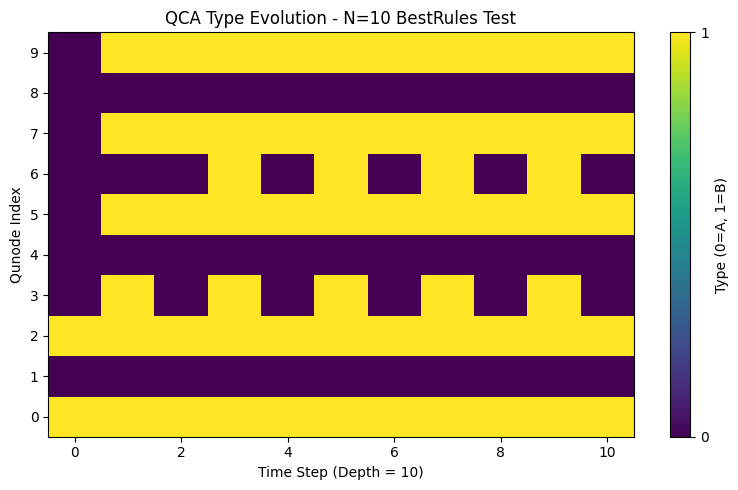


--- Interaction Circuit Visualization ---
Attempting Matplotlib drawer...
IPython display not available. Using text drawer.
     ┌───┐ init_prep      ┌───────────┐           interactions 
q_0: ┤ X ├─────░──────────┤1          ├────────────────░───────
     └───┘     ░     ┌───┐│           │                ░       
q_1: ──────────░─────┤ S ├┤           ├────────────────░───────
     ┌───┐     ░     ├───┤│           │                ░       
q_2: ┤ X ├─────░─────┤ H ├┤           ├────────────────░───────
     └───┘     ░     └───┘│           │     ┌───┐      ░       
q_3: ──────────░──────────┤  Rxx(π/4) ├──■──┤ X ├──────░───────
               ░          │           │  │  └───┘      ░       
q_4: ──────────░──────────┤           ├──┼─────────────░───────
               ░     ┌───┐│           │  │             ░       
q_5: ──────────░─────┤ H ├┤           ├──┼─────────────░───────
               ░     └───┘│           │  │             ░       
q_6: ──────────░──────────┤0          ├──┼─

In [4]:

import numpy as np
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import CXGate, CZGate, RZZGate, RXXGate, RYYGate, SwapGate, HGate, XGate, IGate, SGate, TGate, CCXGate
import matplotlib.pyplot as plt
import time
import os
import json
from typing import List, Optional, Tuple, Dict, Any
from tqdm import tqdm # Keep tqdm for potential long QCA runs if needed
import math

# --- QCA Parameters (same as your GA run) ---
TYPE_A = 0
TYPE_B = 1

# --- QCA Class and is_prime_simple (Ensure these are your latest working versions) ---
# [YOUR QuantumCellularAutomaton CLASS DEFINITION GOES HERE - it should be the one from the GA run]
# [YOUR is_prime_simple FUNCTION GOES HERE - from the GA run]

# --- [PASTE QuantumCellularAutomaton class here] ---
GATES = { # Global GATES dictionary
    "H": HGate(), "X": XGate(), "I": IGate(), "S": SGate(), "T": TGate(),
    "CX": CXGate(), "CZ": CZGate(), "SWAP": SwapGate(), "CCX": CCXGate(),
    "RZZ_PIO4": RZZGate(np.pi/4), "RZZ_PIO2": RZZGate(np.pi/2),
    "RXX_PIO4": RXXGate(np.pi/4), "RYY_PIO4": RYYGate(np.pi/4),
}
class QuantumCellularAutomaton: # Assuming this is your latest working version
    def __init__(self, num_qunodes: int, initial_types: np.ndarray,
                 interaction_config: Dict,
                 type_update_rule_config: Dict,
                 initial_quantum_state_prep: str = "all_zero"
                ):
        self.num_qunodes = num_qunodes
        if len(initial_types) != num_qunodes: raise ValueError("initial_types length mismatch.")
        self.current_types = initial_types.copy()
        self.type_history = [self.current_types.copy()]
        self.quantum_outcome_history = []
        self.interaction_config = interaction_config
        self.type_update_rule_config = type_update_rule_config
        self.initial_quantum_state_prep = initial_quantum_state_prep
        self.simulator = AerSimulator(method='statevector')
        self.circuit_visualization_list = []

    def _get_gate_object(self, gate_name_or_obj):
        if isinstance(gate_name_or_obj, str): return GATES.get(gate_name_or_obj.upper(), GATES["I"])
        elif isinstance(gate_name_or_obj, qiskit.circuit.Instruction): return gate_name_or_obj
        return GATES["I"]

    def _build_interaction_circuit(self) -> QuantumCircuit:
        qc_step = QuantumCircuit(self.num_qunodes, name=f"QCA_Interaction_Step")
        if self.initial_quantum_state_prep == "hadamard_all": [qc_step.h(i) for i in range(self.num_qunodes)]
        elif self.initial_quantum_state_prep == "basis_from_type":
            for i in range(self.num_qunodes):
                if self.current_types[i] == TYPE_B: qc_step.x(i)
        elif self.initial_quantum_state_prep == "mixed_A0_BH":
             for i in range(self.num_qunodes):
                if self.current_types[i] == TYPE_B: qc_step.h(i)
        if self.num_qunodes > 0: qc_step.barrier(label="init_prep")
        interaction_applied_this_step = False; processed_qubits_in_specific_interactions = set()
        if isinstance(self.interaction_config.get("circuit_sequence"), list):
            for op_spec in self.interaction_config["circuit_sequence"]:
                if isinstance(op_spec, tuple) and len(op_spec) == 2:
                    gate_spec, qubit_indices_spec = op_spec
                    if not (isinstance(qubit_indices_spec, (list, tuple)) and \
                            all(isinstance(idx, int) for idx in qubit_indices_spec) and \
                            all(0 <= idx < self.num_qunodes for idx in qubit_indices_spec)): continue
                    qubit_indices = list(qubit_indices_spec)
                    if len(set(qubit_indices)) != len(qubit_indices): continue
                    op_to_apply = self._get_gate_object(gate_spec)
                    if op_to_apply.name.lower() != 'id':
                        if op_to_apply.num_qubits != len(qubit_indices): continue
                        try: qc_step.append(op_to_apply, qubit_indices); interaction_applied_this_step = True
                        except qiskit.exceptions.QiskitError: pass
        else:
            # Fallback for dictionary-based type rules (not used in this best_rules test)
            if self.interaction_config.get("apply_general_nearest_neighbor", False):
                for i in range(self.num_qunodes):
                    q_j_idx = (i + 1) % self.num_qunodes
                    if self.num_qunodes >= 2:
                        type1, type2 = self.current_types[i], self.current_types[q_j_idx]
                        type_key_str = "".join(map(str, sorted((type1, type2))))
                        gate_spec_for_type = self.interaction_config.get(type_key_str, GATES["I"])
                        op_to_apply_type_based = self._get_gate_object(gate_spec_for_type)
                        if op_to_apply_type_based.name.lower() != 'id':
                            try: qc_step.append(op_to_apply_type_based, [i, q_j_idx]); interaction_applied_this_step = True
                            except qiskit.exceptions.QiskitError: pass
        if interaction_applied_this_step and self.num_qunodes > 0 : qc_step.barrier(label="interactions")
        return qc_step

    def _apply_type_update_rule(self, quantum_outcomes_p1: np.ndarray) -> np.ndarray:
        new_types = self.current_types.copy(); rule_params = self.type_update_rule_config
        rule_name = rule_params.get("name", "direct_p1_to_type")
        if rule_name == "direct_p1_to_type":
            threshold = rule_params.get("p1_threshold_for_type_B", 0.5)
            for i in range(self.num_qunodes): new_types[i] = TYPE_B if quantum_outcomes_p1[i] > threshold else TYPE_A
        elif rule_name == "simple_threshold":
            thresh_A2B = rule_params.get("thresh_A_to_B", 0.55); thresh_B2A = rule_params.get("thresh_B_to_A", 0.45)
            for i in range(self.num_qunodes):
                my_p1 = quantum_outcomes_p1[i]
                if self.current_types[i] == TYPE_A and my_p1 > thresh_A2B: new_types[i] = TYPE_B
                elif self.current_types[i] == TYPE_B and my_p1 < thresh_B2A: new_types[i] = TYPE_A
        return new_types

    def step(self) -> np.ndarray:
        interaction_qc = self._build_interaction_circuit()
        if not self.circuit_visualization_list: self.circuit_visualization_list.append(interaction_qc.copy())
        quantum_outcomes_p1 = np.zeros(self.num_qunodes); meaningful_ops = False
        if interaction_qc.num_qubits > 0:
            for instruction in interaction_qc.data:
                if instruction.operation.name.lower() not in ['barrier', 'id', 'snapshot', 'save_statevector']: meaningful_ops = True; break
        if interaction_qc.num_qubits > 0:
            if meaningful_ops or not self.quantum_outcome_history:
                try:
                    final_statevector_obj = Statevector(interaction_qc)
                    for i in range(self.num_qunodes):
                        probs_qi = final_statevector_obj.probabilities([i])
                        quantum_outcomes_p1[i] = probs_qi[1] if len(probs_qi) == 2 else 0.0
                except qiskit.exceptions.QiskitError: quantum_outcomes_p1.fill(0.5)
            else:
                temp_qc_for_p1 = QuantumCircuit(self.num_qunodes)
                if self.initial_quantum_state_prep == "hadamard_all": [temp_qc_for_p1.h(i) for i in range(self.num_qunodes)]
                elif self.initial_quantum_state_prep == "basis_from_type":
                    for i in range(self.num_qunodes):
                        if self.current_types[i] == TYPE_B: temp_qc_for_p1.x(i)
                elif self.initial_quantum_state_prep == "mixed_A0_BH":
                    for i in range(self.num_qunodes):
                        if self.current_types[i] == TYPE_B: temp_qc_for_p1.h(i)
                if temp_qc_for_p1.num_qubits > 0:
                    try:
                        sv = Statevector(temp_qc_for_p1)
                        for i in range(self.num_qunodes):
                            quantum_outcomes_p1[i] = (sv.probabilities([i])[1] if len(sv.probabilities([i]))==2 else 0.0)
                    except qiskit.exceptions.QiskitError: quantum_outcomes_p1.fill(0.5)
        self.quantum_outcome_history.append(quantum_outcomes_p1.copy())
        new_types = self._apply_type_update_rule(quantum_outcomes_p1)
        self.current_types = new_types; self.type_history.append(self.current_types.copy())
        return quantum_outcomes_p1

    def run(self, num_steps: int, verbose: bool = False):
        # For testing, verbose is more useful, tqdm might be too much
        for step_num in range(num_steps):
            p1s = self.step()
            if verbose: print(f"  QCA Test Step {step_num+1}/{num_steps} -> P1s: {np.round(p1s,2)}, Types: {self.current_types}")
        # if verbose: print("  QCA Run for test completed.")

    def get_type_history_as_array(self) -> np.ndarray: return np.array(self.type_history)

    def plot_type_evolution(self, title_suffix: str = "", experiment_label: str = ""):
        history_array = self.get_type_history_as_array()
        if history_array.size == 0 or self.num_qunodes == 0: print("No type history or qunodes to plot."); return
        fig_width = max(8, history_array.shape[0] * 0.3); fig_height = max(4, self.num_qunodes * 0.5)
        plt.figure(figsize=(fig_width, fig_height))
        plt.imshow(history_array.T, cmap='viridis', aspect='auto', interpolation='nearest', origin='lower')
        plt.xlabel(f"Time Step (Depth = {history_array.shape[0] - 1})"); plt.ylabel("Qunode Index")
        title = f"QCA Type Evolution"; plt.title(title + (f" - {experiment_label}" if experiment_label else "")+title_suffix, fontsize=12)
        plt.colorbar(label="Type (0=A, 1=B)", ticks=[TYPE_A, TYPE_B]); plt.yticks(np.arange(self.num_qunodes))
        plt.tight_layout(); plt.show()

    def visualize_interaction_circuit(self, circuit_to_draw: Optional[QuantumCircuit] = None):
        # Visualizes a specific circuit, or the first stored one
        if circuit_to_draw is None and self.circuit_visualization_list:
            circuit_to_draw = self.circuit_visualization_list[0]

        if circuit_to_draw and circuit_to_draw.num_qubits > 0:
            print("\n--- Interaction Circuit Visualization ---")
            try:
                from IPython.display import display
                print("Attempting Matplotlib drawer...")
                display(circuit_to_draw.draw(output='mpl', fold=-1, initial_state=True))
            except ImportError: print("IPython display not available. Using text drawer."); print(circuit_to_draw.draw(output='text', fold=-1))
            except Exception as e: print(f"Error drawing circuit with mpl: {e}. Text:\n{circuit_to_draw.draw(output='text', fold=-1)}")
        elif circuit_to_draw: print("Circuit has no qubits to draw.")
        else: print("No circuit provided or stored for visualization.")
# --- [END QCA CLASS] ---

# --- [PASTE is_prime_simple function here] ---
def is_prime_simple(n: int) -> bool:
    if n < 2: return False
    if n == 2 or n == 3: return True
    if n % 2 == 0 or n % 3 == 0: return False
    i = 5; limit = int(math.sqrt(n))
    while i <= limit:
        if n % i == 0 or n % (i + 2) == 0: return False
        i += 6
    return True
# --- [END is_prime_simple] ---


# --- Function to Test a Specific QCA Rule Set ---
def test_specific_qca_rules(
    qca_rules: Dict,
    numbers_to_test: List[int],
    k_bits_N: int,
    k_bits_factor: int,
    T_max: int,
    test_set_name: str,
    visualize_one_case_N: Optional[int] = None # N for which to visualize circuit/evolution
):
    print(f"\n--- Testing QCA Rules on: {test_set_name} ---")
    correct_factorizations = 0
    correct_prime_factorizations = 0
    partial_success_count = 0 # Found at least one correct factor

    p_reg_start_idx = k_bits_N
    p_reg_end_idx = k_bits_N + k_bits_factor
    q_reg_start_idx = p_reg_end_idx
    q_reg_end_idx = q_reg_start_idx + k_bits_factor
    total_qca_qunodes = q_reg_end_idx

    results = []

    for N_input in numbers_to_test:
        if N_input == 0: continue
        if N_input.bit_length() > k_bits_N:
            print(f"  N={N_input}: SKIPPED (too large for k_bits_N={k_bits_N})")
            results.append({"N": N_input, "status": "skipped_too_large"})
            continue

        initial_types = np.zeros(total_qca_qunodes, dtype=int)
        for i in range(k_bits_N): # MSB first encoding
            if (N_input >> (k_bits_N - 1 - i)) & 1: initial_types[i] = TYPE_B

        qca = QuantumCellularAutomaton(
            num_qunodes=total_qca_qunodes, initial_types=initial_types,
            interaction_config=qca_rules["interaction_config"],
            type_update_rule_config=qca_rules["type_update_rule_config"],
            initial_quantum_state_prep=qca_rules.get("initial_quantum_state_prep", "hadamard_all")
        )
        # For testing, we might want to see QCA evolution steps for a specific case
        run_verbose = (N_input == visualize_one_case_N)
        qca.run(num_steps=T_max, verbose=run_verbose)

        final_types = qca.current_types
        p_pred_binary = final_types[p_reg_start_idx : p_reg_end_idx]
        q_pred_binary = final_types[q_reg_start_idx : q_reg_end_idx]
        p_pred = 0; q_pred = 0
        for bit_type in p_pred_binary: p_pred = (p_pred << 1) | (1 if bit_type == TYPE_B else 0)
        for bit_type in q_pred_binary: q_pred = (q_pred << 1) | (1 if bit_type == TYPE_B else 0)

        is_correct_product = (p_pred * q_pred == N_input) and (p_pred > 1) and (q_pred > 1)
        p_is_prime = is_prime_simple(p_pred)
        q_is_prime = is_prime_simple(q_pred)
        is_correct_prime_prod = is_correct_product and p_is_prime and q_is_prime

        # Check for partial success (at least one factor correct)
        one_factor_correct = False
        if p_pred > 1 and N_input % p_pred == 0: one_factor_correct = True
        if q_pred > 1 and N_input % q_pred == 0: one_factor_correct = True
        if is_correct_product: one_factor_correct = True # Implies both are factors

        result_str = f"  N={N_input}: p_pred={p_pred}, q_pred={q_pred} (p*q = {p_pred*q_pred}). "
        if is_correct_product:
            correct_factorizations += 1
            result_str += "Factors CORRECT. "
            if p_is_prime and q_is_prime:
                correct_prime_factorizations +=1
                result_str += "Both prime."
            elif p_is_prime or q_is_prime: result_str += "One prime."
            else: result_str += "Neither prime."
        else:
            result_str += "Factors INCORRECT."
            if one_factor_correct: result_str += " (One factor found)"


        print(result_str)
        results.append({
            "N": N_input, "p_pred": p_pred, "q_pred": q_pred, "product": p_pred*q_pred,
            "correct_prod": is_correct_product, "p_prime": p_is_prime, "q_prime": q_is_prime,
            "correct_prime_prod": is_correct_prime_prod, "one_factor_correct": one_factor_correct
            })

        if N_input == visualize_one_case_N:
            qca.plot_type_evolution(experiment_label=f"N={N_input} BestRules Test")
            qca.visualize_interaction_circuit() # Will show the static circuit defined by rules

    print(f"\nSummary for '{test_set_name}':")
    print(f"  Total numbers tested: {len(numbers_to_test)}")
    print(f"  Correct factorizations (p*q=N, p>1, q>1): {correct_factorizations} ({correct_factorizations/len(numbers_to_test)*100:.1f}%)")
    print(f"  Correct PRIME factorizations: {correct_prime_factorizations} ({correct_prime_factorizations/len(numbers_to_test)*100:.1f}%)")
    partially_successful_tests = sum(1 for r in results if r.get("one_factor_correct", False) and not r.get("correct_prod", False))
    print(f"  Additionally found one correct factor (but not full factorization): {partially_successful_tests}")
    return results


# --- Main Section to Test the Best Found Algorithm ---
if __name__ == "__main__":
    print("--- Testing Best Evolved QCA Rules for Factorization ---")

    # --- MANUALLY INPUT THE BEST RULES FOUND BY YOUR GA ---
    # This is from your previous GA output
    best_evolved_qca_rules = {
        "interaction_config": {
            "circuit_sequence": [
                ("H", (5,)), # Note: Qiskit expects tuple of ints for single qubit too
                ("RXX_PIO4", (6, 0)),
                ("CX", (3, 7)),
                ("S", (1,)),
                ("X", (3,)),
                ("H", (9,)),
                ("H", (2,)),
                ("SWAP", (7, 6))
            ]
            # "apply_general_nearest_neighbor": False # Assuming circuit_sequence is exclusive
        },
        "type_update_rule_config": {
            "name": "direct_p1_to_type",
            "p1_threshold_for_type_B": 0.03833197151484148
        },
        "initial_quantum_state_prep": "basis_from_type"
    }
    # Ensure the interaction_config matches how your _build_interaction_circuit expects it.
    # If it also needs "apply_general_nearest_neighbor": False, add it.
    # Based on the _build_interaction_circuit, if "circuit_sequence" is present, it takes precedence.

    # Factorization Problem Parameters (must match the GA run that found these rules)
    K_BITS_N_ENCODING = 4
    K_BITS_FACTOR_DECODING = 3
    MAX_QCA_STEPS_FACTORIZATION = 10 # Same T_max used during evolution

    # Define Test Sets
    original_training_set = [6, 10, 14, 15, 21, 22, 25, 26, 33, 34, 35, 38, 39]

    # Unseen composite numbers (within k_bits_N limits)
    # N max is 15 for K_BITS_N_ENCODING = 4.
    # If we increase K_BITS_N_ENCODING for testing, we can test larger N.
    # For now, stick to N <= 15.
    unseen_composites = []
    all_N_up_to_15 = list(range(4, 16)) # Smallest composite is 4
    for n_test in all_N_up_to_15:
        if not is_prime_simple(n_test) and n_test not in original_training_set:
            unseen_composites.append(n_test)
    if not unseen_composites: # If all small composites were in training set
        unseen_composites = [4, 8, 9, 12] # Example if original set was too exhaustive

    prime_test_set = [2, 3, 5, 7, 11, 13] # Should ideally not be "factored" (p*q=N)

    # Run tests
    print("\n*** Testing on Original Training Set ***")
    results_train = test_specific_qca_rules(
        best_evolved_qca_rules, original_training_set,
        K_BITS_N_ENCODING, K_BITS_FACTOR_DECODING, MAX_QCA_STEPS_FACTORIZATION,
        "Original Training Set",
        visualize_one_case_N=10 # Visualize for N=10
    )

    print("\n*** Testing on Unseen Composite Numbers ***")
    results_unseen = test_specific_qca_rules(
        best_evolved_qca_rules, unseen_composites,
        K_BITS_N_ENCODING, K_BITS_FACTOR_DECODING, MAX_QCA_STEPS_FACTORIZATION,
        "Unseen Composites"
    )

    print("\n*** Testing on Prime Numbers (Expect No Factorization) ***")
    results_primes = test_specific_qca_rules(
        best_evolved_qca_rules, prime_test_set,
        K_BITS_N_ENCODING, K_BITS_FACTOR_DECODING, MAX_QCA_STEPS_FACTORIZATION,
        "Prime Numbers Input"
    )

    print("\n--- Overall Test Conclusion ---")
    print("This test evaluated the QCA rules found by the GA.")
    print("Review the 'Correct factorizations' and 'Correct PRIME factorizations' for each set.")
    print("Performance on 'Unseen Composites' indicates generalization ability.")
    print("Performance on 'Prime Numbers Input' indicates if the QCA incorrectly produces factors for primes (ideally, it should output trivial 1*N or fail).")

    # Example: Save results to a file
    # test_summary = {
    #     "best_rules": best_evolved_qca_rules,
    #     "training_set_results": results_train,
    #     "unseen_composites_results": results_unseen,
    #     "prime_test_results": results_primes
    # }
    # with open("best_qca_factorizer_test_summary.json", "w") as f:
    #     json.dump(test_summary, f, indent=2)
    # print("\nTest summary saved to best_qca_factorizer_test_summary.json")

--- Analyzing Best Evolved QCA Factorization Algorithm ---

--- Analyzing Winning QCA Circuit for N = 10 ---
Initial Classical Types (N encoded in Q0-Q3): [1 0 1 0]
  p_reg (Q4-Q6) initial: [0 0 0]
  q_reg (Q7-Q9) initial: [0 0 0]

Statevector after Initial Preparation:
  Q4: P(|0>)=1.000, P(|1>)=0.000
  Q5: P(|0>)=1.000, P(|1>)=0.000
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|0>)=1.000, P(|1>)=0.000
  Q9: P(|0>)=1.000, P(|1>)=0.000
  Top 10 amplitudes (state | probability):
    |0000000101> : 1.0000 (amp: (1+0j))

Applying 8-gate Circuit Sequence:

Step 1: Applying H to qubits (5,)
  Q4: P(|0>)=1.000, P(|1>)=0.000
  Q5: P(|0>)=0.500, P(|1>)=0.500
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|0>)=1.000, P(|1>)=0.000
  Q9: P(|0>)=1.000, P(|1>)=0.000
  Top 10 amplitudes after H(5,):
    |0000100101> : 0.5000 (amp: (0.7071067811865475+0j))
    |0000000101> : 0.5000 (amp: (0.7071067811865475+0j))

Step 2: Applying RXX_PIO4 to qub

<ipython-input-5-f87f84368766>:163: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(history_array.T, cmap='viridis', aspect='auto', interpolation='nearest', origin='lower',


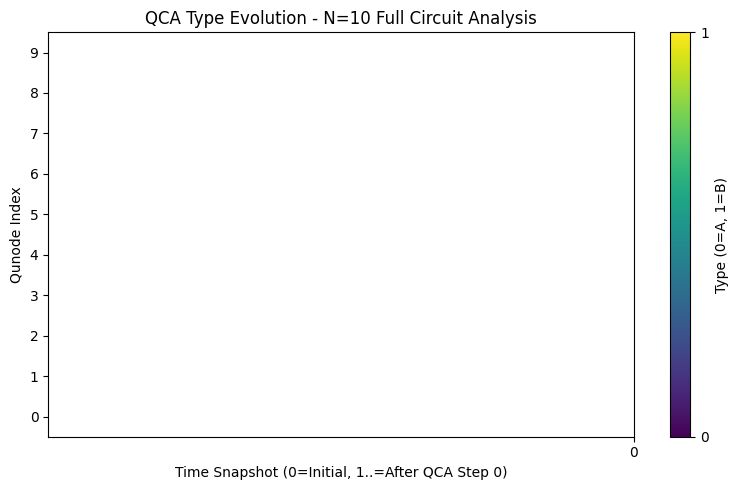


--- Analyzing Winning QCA Circuit for N = 6 ---
Initial Classical Types (N encoded in Q0-Q3): [0 1 1 0]
  p_reg (Q4-Q6) initial: [0 0 0]
  q_reg (Q7-Q9) initial: [0 0 0]

Statevector after Initial Preparation:
  Q4: P(|0>)=1.000, P(|1>)=0.000
  Q5: P(|0>)=1.000, P(|1>)=0.000
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|0>)=1.000, P(|1>)=0.000
  Q9: P(|0>)=1.000, P(|1>)=0.000
  Top 8 amplitudes (state | probability):
    |0000000110> : 1.0000 (amp: (1+0j))

Applying 8-gate Circuit Sequence:

Step 1: Applying H to qubits (5,)
  Q4: P(|0>)=1.000, P(|1>)=0.000
  Q5: P(|0>)=0.500, P(|1>)=0.500
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|0>)=1.000, P(|1>)=0.000
  Q9: P(|0>)=1.000, P(|1>)=0.000
  Top 8 amplitudes after H(5,):
    |0000100110> : 0.5000 (amp: (0.7071067811865475+0j))
    |0000000110> : 0.5000 (amp: (0.7071067811865475+0j))

Step 2: Applying RXX_PIO4 to qubits (6, 0)
  Q4: P(|0>)=1.000, P(|1>)=0.000
  Q5: P(|0>)=0.500

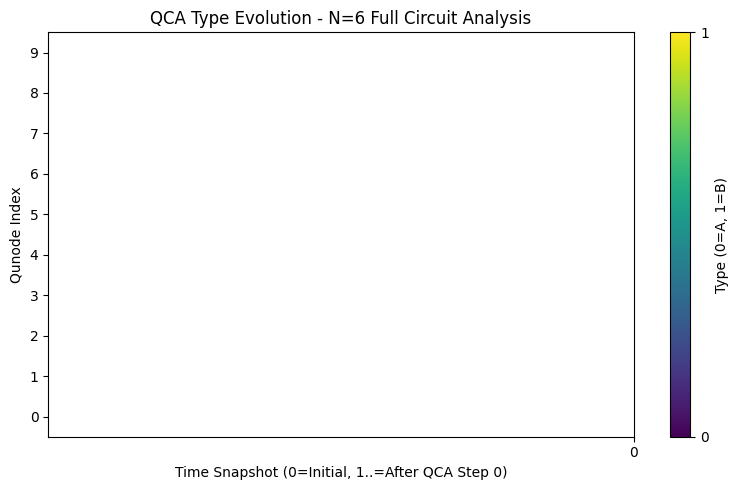

In [5]:

import numpy as np
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator # Correct import for AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city, plot_bloch_multivector, plot_histogram
from qiskit.circuit.library import CXGate, CZGate, RZZGate, RXXGate, RYYGate, SwapGate, HGate, XGate, IGate, SGate, TGate, CCXGate
import matplotlib.pyplot as plt
import time
import os
import json
from typing import List, Optional, Tuple, Dict, Any
import math

# --- QCA Parameters ---
TYPE_A = 0
TYPE_B = 1

# --- QCA Class (Modified for detailed step-through analysis) ---
GATES = { # Global GATES dictionary
    "H": HGate(), "X": XGate(), "I": IGate(), "S": SGate(), "T": TGate(),
    "CX": CXGate(), "CZ": CZGate(), "SWAP": SwapGate(), "CCX": CCXGate(),
    "RZZ_PIO4": RZZGate(np.pi/4), "RZZ_PIO2": RZZGate(np.pi/2),
    "RXX_PIO4": RXXGate(np.pi/4), "RYY_PIO4": RYYGate(np.pi/4),
}
class QuantumCellularAutomaton:
    def __init__(self, num_qunodes: int, initial_types: np.ndarray,
                 interaction_config: Dict,
                 type_update_rule_config: Dict,
                 initial_quantum_state_prep: str = "all_zero"
                ):
        self.num_qunodes = num_qunodes
        if len(initial_types) != num_qunodes: raise ValueError("initial_types length mismatch.")
        self.current_types = initial_types.copy()
        self.qca_quantum_state = None
        self.type_history = [self.current_types.copy()]
        self.quantum_outcome_history = []
        self.interaction_config = interaction_config
        self.type_update_rule_config = type_update_rule_config
        self.initial_quantum_state_prep = initial_quantum_state_prep
        self.full_interaction_circuit_for_viz = None

    def _get_gate_object(self, gate_name_or_obj):
        if isinstance(gate_name_or_obj, str): return GATES.get(gate_name_or_obj.upper(), GATES["I"])
        elif isinstance(gate_name_or_obj, qiskit.circuit.Instruction): return gate_name_or_obj
        return GATES["I"]

    def _prepare_initial_quantum_state(self) -> QuantumCircuit:
        qc_prep = QuantumCircuit(self.num_qunodes, name="InitialStatePrep")
        if self.initial_quantum_state_prep == "hadamard_all": [qc_prep.h(i) for i in range(self.num_qunodes)]
        elif self.initial_quantum_state_prep == "basis_from_type":
            for i in range(self.num_qunodes):
                if self.current_types[i] == TYPE_B: qc_prep.x(i)
        elif self.initial_quantum_state_prep == "mixed_A0_BH":
             for i in range(self.num_qunodes):
                if self.current_types[i] == TYPE_B: qc_prep.h(i)
        return qc_prep

    def initialize_statevector(self):
        prep_qc = self._prepare_initial_quantum_state()
        if prep_qc.num_qubits > 0:
            self.qca_quantum_state = Statevector(prep_qc)
        elif self.num_qunodes == 0 :
             self.qca_quantum_state = Statevector(np.array([1.+0.j]))
        else:
            self.qca_quantum_state = Statevector(QuantumCircuit(self.num_qunodes))

    def apply_gate_and_get_statevector(self, gate_spec, qubit_indices_spec) -> Optional[Statevector]:
        if self.qca_quantum_state is None:
            print("Error: QCA statevector not initialized. Call initialize_statevector() first.")
            return None

        op_to_apply = self._get_gate_object(gate_spec)
        if op_to_apply.name.lower() == 'id': return self.qca_quantum_state

        if not (isinstance(qubit_indices_spec, (list, tuple)) and \
                all(isinstance(idx, int) for idx in qubit_indices_spec) and \
                all(0 <= idx < self.num_qunodes for idx in qubit_indices_spec)):
            print(f"Warning: Invalid qubit indices '{qubit_indices_spec}' for gate {op_to_apply.name}. Skipping.")
            return self.qca_quantum_state

        qubit_indices = list(qubit_indices_spec)
        if len(set(qubit_indices)) != len(qubit_indices):
            print(f"Warning: Duplicate qubit indices in {qubit_indices} for gate {op_to_apply.name}. Skipping.")
            return self.qca_quantum_state
        if op_to_apply.num_qubits != len(qubit_indices):
            print(f"Warning: Gate {op_to_apply.name} (arity {op_to_apply.num_qubits}) incompatible with qubit list length {len(qubit_indices)}. Skipping.")
            return self.qca_quantum_state

        temp_qc = QuantumCircuit(self.num_qunodes)
        try:
            temp_qc.append(op_to_apply, qubit_indices)
            self.qca_quantum_state = self.qca_quantum_state.evolve(temp_qc)
            return self.qca_quantum_state
        except qiskit.exceptions.QiskitError as e:
            print(f"Error applying gate {op_to_apply.name} to {qubit_indices}: {e}")
            return self.qca_quantum_state

    def _build_full_interaction_circuit_for_step(self) -> QuantumCircuit:
        qc_full_step = self._prepare_initial_quantum_state()
        if self.num_qunodes > 0: qc_full_step.barrier(label="init_prep")
        interaction_applied_this_step = False
        if isinstance(self.interaction_config.get("circuit_sequence"), list):
            for op_spec_item in self.interaction_config["circuit_sequence"]:
                if isinstance(op_spec_item, tuple) and len(op_spec_item) == 2:
                    gate_s, q_indices_s = op_spec_item
                    if not (isinstance(q_indices_s, (list, tuple)) and \
                            all(isinstance(idx, int) for idx in q_indices_s) and \
                            all(0 <= idx < self.num_qunodes for idx in q_indices_s)): continue
                    q_indices = list(q_indices_s)
                    if len(set(q_indices)) != len(q_indices): continue
                    op = self._get_gate_object(gate_s)
                    if op.name.lower() != 'id':
                        if op.num_qubits != len(q_indices): continue
                        try: qc_full_step.append(op, q_indices); interaction_applied_this_step = True
                        except qiskit.exceptions.QiskitError: pass
        if interaction_applied_this_step and self.num_qunodes > 0: qc_full_step.barrier(label="interactions")
        self.full_interaction_circuit_for_viz = qc_full_step
        return qc_full_step

    def _apply_type_update_rule(self, quantum_outcomes_p1: np.ndarray) -> np.ndarray:
        new_types = self.current_types.copy(); rule_params = self.type_update_rule_config
        rule_name = rule_params.get("name", "direct_p1_to_type")
        if rule_name == "direct_p1_to_type":
            threshold = rule_params.get("p1_threshold_for_type_B", 0.5)
            for i in range(self.num_qunodes): new_types[i] = TYPE_B if quantum_outcomes_p1[i] > threshold else TYPE_A
        elif rule_name == "simple_threshold":
            thresh_A2B = rule_params.get("thresh_A_to_B", 0.55); thresh_B2A = rule_params.get("thresh_B_to_A", 0.45)
            for i in range(self.num_qunodes):
                my_p1 = quantum_outcomes_p1[i]
                if self.current_types[i] == TYPE_A and my_p1 > thresh_A2B: new_types[i] = TYPE_B
                elif self.current_types[i] == TYPE_B and my_p1 < thresh_B2A: new_types[i] = TYPE_A
        return new_types

    def run_one_step_for_analysis(self, verbose_level=0):
        full_qc = self._build_full_interaction_circuit_for_step()
        quantum_outcomes_p1 = np.zeros(self.num_qunodes)
        if full_qc.num_qubits > 0:
            try:
                final_sv = Statevector(full_qc)
                self.qca_quantum_state = final_sv
                for i in range(self.num_qunodes):
                    probs_qi = final_sv.probabilities([i])
                    quantum_outcomes_p1[i] = probs_qi[1] if len(probs_qi) == 2 else 0.0
            except qiskit.exceptions.QiskitError as e:
                print(f"Error during full step simulation for analysis: {e}. P1s set to 0.5.")
                quantum_outcomes_p1.fill(0.5)

        self.quantum_outcome_history.append(quantum_outcomes_p1.copy())
        new_types = self._apply_type_update_rule(quantum_outcomes_p1)

        if verbose_level >= 1:
            print(f"  Final P(|1⟩) after 1 circuit execution: {np.round(quantum_outcomes_p1, 3)}")
            print(f"  Derived Classical Types: {new_types}")
        return new_types, quantum_outcomes_p1

    def plot_type_evolution(self, title_suffix: str = "", experiment_label: str = ""):
        history_array = np.array(self.type_history)
        if history_array.size == 0 or self.num_qunodes == 0: print("No type history or qunodes to plot."); return
        num_snapshots = history_array.shape[0]
        fig_width = max(8, num_snapshots * 1.0); fig_height = max(4, self.num_qunodes * 0.5)
        plt.figure(figsize=(fig_width, fig_height))
        plt.imshow(history_array.T, cmap='viridis', aspect='auto', interpolation='nearest', origin='lower',
                   extent=[-0.5, num_snapshots -1 -0.5 , -0.5, self.num_qunodes - 0.5])
        plt.xlabel(f"Time Snapshot (0=Initial, 1..=After QCA Step {num_snapshots-1})"); plt.ylabel("Qunode Index")
        title = f"QCA Type Evolution"; plt.title(title + (f" - {experiment_label}" if experiment_label else "")+title_suffix, fontsize=12)
        plt.colorbar(label="Type (0=A, 1=B)", ticks=[TYPE_A, TYPE_B]);
        if self.num_qunodes > 0: plt.yticks(np.arange(self.num_qunodes))
        if num_snapshots > 0: plt.xticks(np.arange(num_snapshots))
        plt.tight_layout(); plt.show()

    def visualize_full_interaction_circuit(self):
        if self.full_interaction_circuit_for_viz and self.full_interaction_circuit_for_viz.num_qubits > 0:
            print("\n--- Full Interaction Circuit (One Step) Visualization ---")
            try:
                from IPython.display import display
                display(self.full_interaction_circuit_for_viz.draw(output='mpl', fold=-1, initial_state=True))
            except ImportError: print("IPython display not available. Text:\n", self.full_interaction_circuit_for_viz.draw(output='text', fold=-1))
            except Exception as e: print(f"MPL draw error: {e}. Text:\n{self.full_interaction_circuit_for_viz.draw(output='text', fold=-1)}")
        elif self.full_interaction_circuit_for_viz: print("Circuit has no qubits.")
        else: print("No full interaction circuit built or stored for visualization.")
# --- [END QCA CLASS] ---

# --- [PASTE is_prime_simple function here] ---
def is_prime_simple(n: int) -> bool:
    if n < 2: return False
    if n == 2 or n == 3: return True
    if n % 2 == 0 or n % 3 == 0: return False
    i = 5; limit = int(math.sqrt(n))
    while i <= limit:
        if n % i == 0 or n % (i + 2) == 0: return False
        i += 6
    return True
# --- [END is_prime_simple] ---

def analyze_winning_circuit(
    qca_rules: Dict,
    N_input: int,
    k_bits_N: int,
    k_bits_factor: int,
    show_statevector_probs_for_qubits: Optional[List[int]] = None,
    max_amplitudes_to_show: int = 8
):
    print(f"\n--- Analyzing Winning QCA Circuit for N = {N_input} ---")
    p_reg_start_idx = k_bits_N; p_reg_end_idx = k_bits_N + k_bits_factor
    q_reg_start_idx = p_reg_end_idx; q_reg_end_idx = q_reg_start_idx + k_bits_factor
    total_qca_qunodes = q_reg_end_idx
    initial_types = np.zeros(total_qca_qunodes, dtype=int)
    for i in range(k_bits_N):
        if (N_input >> (k_bits_N - 1 - i)) & 1: initial_types[i] = TYPE_B

    print(f"Initial Classical Types (N encoded in Q0-Q{k_bits_N-1}): {initial_types[:k_bits_N]}")
    print(f"  p_reg (Q{p_reg_start_idx}-Q{p_reg_end_idx-1}) initial: {initial_types[p_reg_start_idx:p_reg_end_idx]}")
    print(f"  q_reg (Q{q_reg_start_idx}-Q{q_reg_end_idx-1}) initial: {initial_types[q_reg_start_idx:q_reg_end_idx]}")

    qca = QuantumCellularAutomaton(
        num_qunodes=total_qca_qunodes, initial_types=initial_types,
        interaction_config=qca_rules["interaction_config"],
        type_update_rule_config=qca_rules["type_update_rule_config"],
        initial_quantum_state_prep=qca_rules.get("initial_quantum_state_prep", "hadamard_all")
    )

    qca.initialize_statevector() # Sets qca.qca_quantum_state
    print("\nStatevector after Initial Preparation:")
    if qca.qca_quantum_state and qca.qca_quantum_state.num_qubits > 0:
        if show_statevector_probs_for_qubits:
            for q_idx in show_statevector_probs_for_qubits:
                if 0 <= q_idx < qca.num_qunodes:
                    probs = qca.qca_quantum_state.probabilities([q_idx])
                    print(f"  Q{q_idx}: P(|0>)={probs[0]:.3f}, P(|1>)={probs[1]:.3f}")
        sv_data = qca.qca_quantum_state.data; probs_data = np.abs(sv_data)**2
        sorted_indices = np.argsort(probs_data)[::-1]
        print(f"  Top {max_amplitudes_to_show} amplitudes (state | probability):")
        for i in range(min(max_amplitudes_to_show, len(sorted_indices))):
            idx = sorted_indices[i]
            if probs_data[idx] > 1e-6:
                 binary_state = format(idx, f'0{qca.num_qunodes}b')
                 print(f"    |{binary_state}> : {probs_data[idx]:.4f} (amp: {sv_data[idx]})")

    circuit_sequence = qca_rules.get("interaction_config", {}).get("circuit_sequence", [])
    print(f"\nApplying {len(circuit_sequence)}-gate Circuit Sequence:")
    current_sv_for_trace = qca.qca_quantum_state
    for op_idx, op_spec in enumerate(circuit_sequence):
        # Ensure op_spec is a tuple for the parsing logic in apply_gate_and_get_statevector
        if isinstance(op_spec, tuple) and len(op_spec) == 2:
            gate_s, q_indices_s = op_spec # q_indices_s should already be a tuple from rule definition
            print(f"\nStep {op_idx + 1}: Applying {gate_s} to qubits {q_indices_s}")

            new_sv_trace = qca.apply_gate_and_get_statevector(gate_s, q_indices_s) # qca_quantum_state is updated internally

            if qca.qca_quantum_state: # Check the internal state after application
                current_sv_for_trace = qca.qca_quantum_state # Update trace SV to internal SV
                if show_statevector_probs_for_qubits:
                    for q_idx in show_statevector_probs_for_qubits:
                         if 0 <= q_idx < qca.num_qunodes:
                            probs = current_sv_for_trace.probabilities([q_idx])
                            print(f"  Q{q_idx}: P(|0>)={probs[0]:.3f}, P(|1>)={probs[1]:.3f}")
                sv_data_trace = current_sv_for_trace.data; probs_data_trace = np.abs(sv_data_trace)**2
                sorted_indices_trace = np.argsort(probs_data_trace)[::-1]
                print(f"  Top {max_amplitudes_to_show} amplitudes after {gate_s}{q_indices_s}:")
                for i in range(min(max_amplitudes_to_show, len(sorted_indices_trace))):
                    idx_trace = sorted_indices_trace[i]
                    if probs_data_trace[idx_trace] > 1e-6:
                         binary_state_trace = format(idx_trace, f'0{qca.num_qunodes}b')
                         print(f"    |{binary_state_trace}> : {probs_data_trace[idx_trace]:.4f} (amp: {sv_data_trace[idx_trace]})")
            else: print(f"  Statevector became invalid after {gate_s}. Stopping trace."); break
        else: print(f"  Skipping invalid operation spec for trace: {op_spec}")

    # Reset QCA's classical state and history to run the full step for final types
    qca.current_types = initial_types
    qca.type_history = [initial_types.copy()]
    qca.quantum_outcome_history = []
    final_classical_types_after_circuit, final_quantum_outcomes_p1 = qca.run_one_step_for_analysis(verbose_level=0)

    p_pred_binary = final_classical_types_after_circuit[p_reg_start_idx : p_reg_end_idx]
    q_pred_binary = final_classical_types_after_circuit[q_reg_start_idx : q_reg_end_idx]
    p_pred = 0; q_pred = 0
    for bit_type in p_pred_binary: p_pred = (p_pred << 1) | (1 if bit_type == TYPE_B else 0)
    for bit_type in q_pred_binary: q_pred = (q_pred << 1) | (1 if bit_type == TYPE_B else 0)

    print("\n--- Final State after Full Circuit Execution and Type Update (from QCA perspective) ---")
    print(f"Final P(|1⟩) values from QCA step: {np.round(final_quantum_outcomes_p1, 3)}")
    print(f"Final Classical Types from QCA step: {final_classical_types_after_circuit}")
    print(f"  p_reg: {p_pred_binary}, Decoded p_pred: {p_pred}")
    print(f"  q_reg: {q_pred_binary}, Decoded q_pred: {q_pred}")
    print(f"Product p_pred * q_pred = {p_pred * q_pred} (Expected N = {N_input})")

    qca.visualize_full_interaction_circuit() # This uses self.full_interaction_circuit_for_viz
    qca.plot_type_evolution(experiment_label=f"N={N_input} Full Circuit Analysis")

# --- Main Section to Analyze the Best Evolved Algorithm ---
if __name__ == "__main__":
    print("--- Analyzing Best Evolved QCA Factorization Algorithm ---")

    best_evolved_qca_rules = {
      "interaction_config": {
        "circuit_sequence": [
          ("H", (5,)),
          ("RXX_PIO4", (6, 0)),
          ("CX", (3, 7)),
          ("S", (1,)),
          ("X", (3,)),
          ("H", (9,)),
          ("H", (2,)),
          ("SWAP", (7, 6))
        ]
      },
      "type_update_rule_config": {
        "name": "direct_p1_to_type",
        "p1_threshold_for_type_B": 0.03833197151484148
      },
      "initial_quantum_state_prep": "basis_from_type"
    }
    # Ensure all qubit indices in circuit_sequence's operations are tuples.
    # The previous correction loop for this is good and can be kept if loading from JSON
    # where lists might appear instead of tuples for qubit indices.
    # For this direct definition, it's already correct.

    K_BITS_N_ENCODING = 4
    K_BITS_FACTOR_DECODING = 3

    p_indices = list(range(K_BITS_N_ENCODING, K_BITS_N_ENCODING + K_BITS_FACTOR_DECODING))
    q_indices = list(range(K_BITS_N_ENCODING + K_BITS_FACTOR_DECODING, K_BITS_N_ENCODING + 2 * K_BITS_FACTOR_DECODING))
    output_qubit_indices_to_watch = p_indices + q_indices

    analyze_winning_circuit(
        best_evolved_qca_rules, N_input=10, k_bits_N=K_BITS_N_ENCODING,
        k_bits_factor=K_BITS_FACTOR_DECODING,
        show_statevector_probs_for_qubits = output_qubit_indices_to_watch,
        max_amplitudes_to_show=10
    )

    analyze_winning_circuit(
        best_evolved_qca_rules, N_input=6, k_bits_N=K_BITS_N_ENCODING,
        k_bits_factor=K_BITS_FACTOR_DECODING,
        show_statevector_probs_for_qubits = output_qubit_indices_to_watch,
        max_amplitudes_to_show=8 # Corrected variable name from previous response
    )

--- Analyzing NEW Best Evolved QCA Factorization Algorithm ---


**************************************************************
**********           ANALYZING FOR N = 10           **********
**************************************************************

--- Analyzing Winning QCA Circuit for N = 10 ---
Initial Classical Types (N encoded in Q0-Q3): [1 0 1 0]
  p_reg (Q4-Q6) initial: [0 0 0]
  q_reg (Q7-Q9) initial: [0 0 0]

Statevector after Initial Preparation:
  Q4: P(|0>)=1.000, P(|1>)=0.000
  Q5: P(|0>)=1.000, P(|1>)=0.000
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|0>)=1.000, P(|1>)=0.000
  Q9: P(|0>)=1.000, P(|1>)=0.000
  Top 10 amplitudes (state | probability):
    |0000000101> : 1.0000 (amp: (1+0j))

Applying 8-gate Circuit Sequence:

Step 1: Applying RYY_PIO4 to qubits (3, 4)
  Q4: P(|0>)=0.854, P(|1>)=0.146
  Q5: P(|0>)=1.000, P(|1>)=0.000
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|0>)=1.000, P(|1>)=0.000
  Q9: P(|

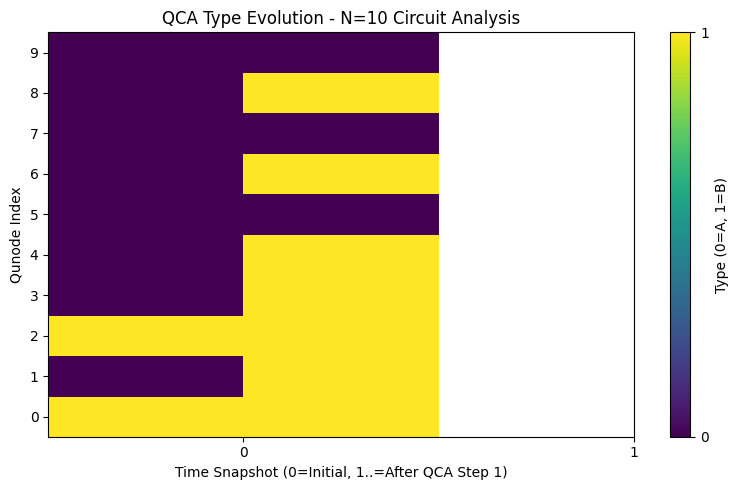



**************************************************************
**********           ANALYZING FOR N = 14           **********
**************************************************************

--- Analyzing Winning QCA Circuit for N = 14 ---
Initial Classical Types (N encoded in Q0-Q3): [1 1 1 0]
  p_reg (Q4-Q6) initial: [0 0 0]
  q_reg (Q7-Q9) initial: [0 0 0]

Statevector after Initial Preparation:
  Q4: P(|0>)=1.000, P(|1>)=0.000
  Q5: P(|0>)=1.000, P(|1>)=0.000
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|0>)=1.000, P(|1>)=0.000
  Q9: P(|0>)=1.000, P(|1>)=0.000
  Top 10 amplitudes (state | probability):
    |0000000111> : 1.0000 (amp: (1+0j))

Applying 8-gate Circuit Sequence:

Step 1: Applying RYY_PIO4 to qubits (3, 4)
  Q4: P(|0>)=0.854, P(|1>)=0.146
  Q5: P(|0>)=1.000, P(|1>)=0.000
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|0>)=1.000, P(|1>)=0.000
  Q9: P(|0>)=1.000, P(|1>)=0.000
  Top 10 amplitudes after RYY_PIO4(3, 4

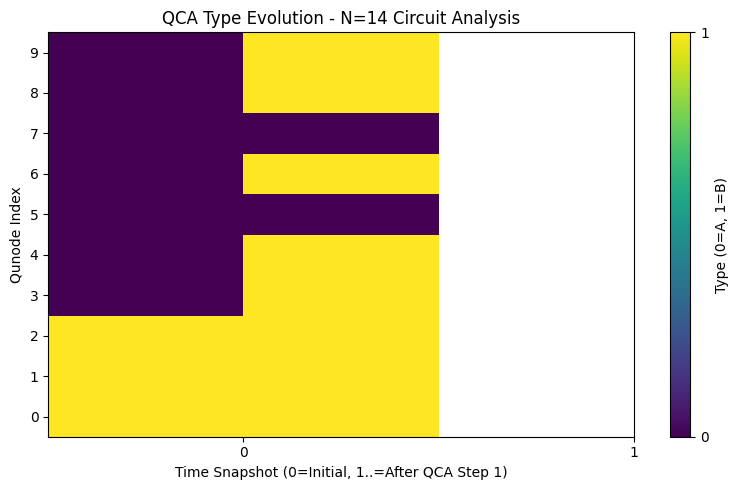



**************************************************************
**********            ANALYZING FOR N = 6           **********
**************************************************************

--- Analyzing Winning QCA Circuit for N = 6 ---
Initial Classical Types (N encoded in Q0-Q3): [0 1 1 0]
  p_reg (Q4-Q6) initial: [0 0 0]
  q_reg (Q7-Q9) initial: [0 0 0]

Statevector after Initial Preparation:
  Q4: P(|0>)=1.000, P(|1>)=0.000
  Q5: P(|0>)=1.000, P(|1>)=0.000
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|0>)=1.000, P(|1>)=0.000
  Q9: P(|0>)=1.000, P(|1>)=0.000
  Top 10 amplitudes (state | probability):
    |0000000110> : 1.0000 (amp: (1+0j))

Applying 8-gate Circuit Sequence:

Step 1: Applying RYY_PIO4 to qubits (3, 4)
  Q4: P(|0>)=0.854, P(|1>)=0.146
  Q5: P(|0>)=1.000, P(|1>)=0.000
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|0>)=1.000, P(|1>)=0.000
  Q9: P(|0>)=1.000, P(|1>)=0.000
  Top 10 amplitudes after RYY_PIO4(3, 4)

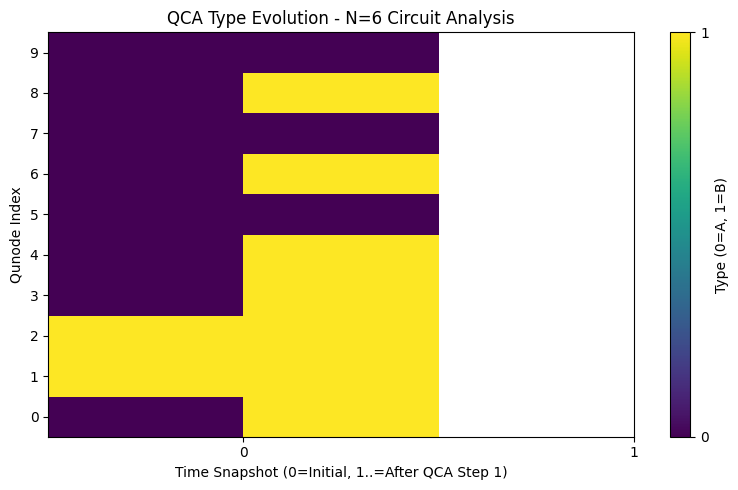

In [6]:

import numpy as np
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator # Correct import for AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city, plot_bloch_multivector, plot_histogram
from qiskit.circuit.library import CXGate, CZGate, RZZGate, RXXGate, RYYGate, SwapGate, HGate, XGate, IGate, SGate, TGate, CCXGate
import matplotlib.pyplot as plt
import time
import os
import json
from typing import List, Optional, Tuple, Dict, Any
import math

# --- QCA Parameters ---
TYPE_A = 0
TYPE_B = 1

# --- GATES Definition ---
GATES = {
    "H": HGate(), "X": XGate(), "I": IGate(), "S": SGate(), "T": TGate(),
    "CX": CXGate(), "CZ": CZGate(), "SWAP": SwapGate(), "CCX": CCXGate(),
    "RZZ_PIO4": RZZGate(np.pi/4), "RZZ_PIO2": RZZGate(np.pi/2),
    "RXX_PIO4": RXXGate(np.pi/4), "RYY_PIO4": RYYGate(np.pi/4),
}

# --- QuantumCellularAutomaton Class (Analysis Version) ---
class QuantumCellularAutomaton:
    def __init__(self, num_qunodes: int, initial_types: np.ndarray,
                 interaction_config: Dict,
                 type_update_rule_config: Dict,
                 initial_quantum_state_prep: str = "all_zero"
                ):
        self.num_qunodes = num_qunodes
        if len(initial_types) != num_qunodes: raise ValueError("initial_types length mismatch.")
        self.current_types = initial_types.copy()
        self.qca_quantum_state = None
        self.type_history = [self.current_types.copy()]
        self.quantum_outcome_history = []
        self.interaction_config = interaction_config
        self.type_update_rule_config = type_update_rule_config
        self.initial_quantum_state_prep = initial_quantum_state_prep
        self.full_interaction_circuit_for_viz = None

    def _get_gate_object(self, gate_name_or_obj):
        if isinstance(gate_name_or_obj, str): return GATES.get(gate_name_or_obj.upper(), GATES["I"])
        elif isinstance(gate_name_or_obj, qiskit.circuit.Instruction): return gate_name_or_obj
        return GATES["I"]

    def _prepare_initial_quantum_state(self) -> QuantumCircuit:
        qc_prep = QuantumCircuit(self.num_qunodes, name="InitialStatePrep")
        if self.initial_quantum_state_prep == "hadamard_all": [qc_prep.h(i) for i in range(self.num_qunodes)]
        elif self.initial_quantum_state_prep == "basis_from_type":
            for i in range(self.num_qunodes):
                if self.current_types[i] == TYPE_B: qc_prep.x(i)
        elif self.initial_quantum_state_prep == "mixed_A0_BH":
             for i in range(self.num_qunodes):
                if self.current_types[i] == TYPE_B: qc_prep.h(i)
        return qc_prep

    def initialize_statevector(self):
        prep_qc = self._prepare_initial_quantum_state()
        if prep_qc.num_qubits > 0:
            self.qca_quantum_state = Statevector(prep_qc)
        elif self.num_qunodes == 0 :
             self.qca_quantum_state = Statevector(np.array([1.+0.j]))
        else:
            self.qca_quantum_state = Statevector(QuantumCircuit(self.num_qunodes))

    def apply_gate_and_get_statevector(self, gate_spec, qubit_indices_spec) -> Optional[Statevector]:
        if self.qca_quantum_state is None:
            print("Error: QCA statevector not initialized. Call initialize_statevector() first.")
            return None

        op_to_apply = self._get_gate_object(gate_spec)
        if op_to_apply.name.lower() == 'id': return self.qca_quantum_state

        if not (isinstance(qubit_indices_spec, (list, tuple)) and \
                all(isinstance(idx, int) for idx in qubit_indices_spec) and \
                all(0 <= idx < self.num_qunodes for idx in qubit_indices_spec)):
            print(f"Warning: Invalid qubit indices '{qubit_indices_spec}' for gate {op_to_apply.name}. Skipping.")
            return self.qca_quantum_state

        qubit_indices = list(qubit_indices_spec)
        if len(set(qubit_indices)) != len(qubit_indices):
            print(f"Warning: Duplicate qubit indices in {qubit_indices} for gate {op_to_apply.name}. Skipping.")
            return self.qca_quantum_state
        if op_to_apply.num_qubits != len(qubit_indices):
            print(f"Warning: Gate {op_to_apply.name} (arity {op_to_apply.num_qubits}) incompatible with qubit list length {len(qubit_indices)}. Skipping.")
            return self.qca_quantum_state

        temp_qc = QuantumCircuit(self.num_qunodes)
        try:
            temp_qc.append(op_to_apply, qubit_indices)
            self.qca_quantum_state = self.qca_quantum_state.evolve(temp_qc)
            return self.qca_quantum_state
        except qiskit.exceptions.QiskitError as e:
            print(f"Error applying gate {op_to_apply.name} to {qubit_indices}: {e}")
            return self.qca_quantum_state # Return previous state on error

    def _build_full_interaction_circuit_for_step(self) -> QuantumCircuit:
        qc_full_step = self._prepare_initial_quantum_state()
        if self.num_qunodes > 0: qc_full_step.barrier(label="init_prep")
        interaction_applied_this_step = False
        if isinstance(self.interaction_config.get("circuit_sequence"), list):
            for op_spec_item in self.interaction_config["circuit_sequence"]:
                if isinstance(op_spec_item, tuple) and len(op_spec_item) == 2:
                    gate_s, q_indices_s = op_spec_item
                    if not (isinstance(q_indices_s, (list, tuple)) and \
                            all(isinstance(idx, int) for idx in q_indices_s) and \
                            all(0 <= idx < self.num_qunodes for idx in q_indices_s)): continue
                    q_indices = list(q_indices_s)
                    if len(set(q_indices)) != len(q_indices): continue
                    op = self._get_gate_object(gate_s)
                    if op.name.lower() != 'id':
                        if op.num_qubits != len(q_indices): continue
                        try: qc_full_step.append(op, q_indices); interaction_applied_this_step = True
                        except qiskit.exceptions.QiskitError: pass # Mute for EA-like execution
        if interaction_applied_this_step and self.num_qunodes > 0: qc_full_step.barrier(label="interactions")
        self.full_interaction_circuit_for_viz = qc_full_step
        return qc_full_step

    def _apply_type_update_rule(self, quantum_outcomes_p1: np.ndarray) -> np.ndarray:
        new_types = self.current_types.copy(); rule_params = self.type_update_rule_config
        rule_name = rule_params.get("name", "direct_p1_to_type")
        if rule_name == "direct_p1_to_type":
            threshold = rule_params.get("p1_threshold_for_type_B", 0.5)
            for i in range(self.num_qunodes): new_types[i] = TYPE_B if quantum_outcomes_p1[i] > threshold else TYPE_A
        elif rule_name == "simple_threshold":
            thresh_A2B = rule_params.get("thresh_A_to_B", 0.55); thresh_B2A = rule_params.get("thresh_B_to_A", 0.45)
            for i in range(self.num_qunodes):
                my_p1 = quantum_outcomes_p1[i]
                if self.current_types[i] == TYPE_A and my_p1 > thresh_A2B: new_types[i] = TYPE_B
                elif self.current_types[i] == TYPE_B and my_p1 < thresh_B2A: new_types[i] = TYPE_A
        return new_types

    def run_one_step_for_analysis(self, verbose_level=0):
        full_qc = self._build_full_interaction_circuit_for_step()
        quantum_outcomes_p1 = np.zeros(self.num_qunodes)
        if full_qc.num_qubits > 0:
            try:
                final_sv = Statevector(full_qc)
                self.qca_quantum_state = final_sv
                for i in range(self.num_qunodes):
                    probs_qi = final_sv.probabilities([i])
                    quantum_outcomes_p1[i] = probs_qi[1] if len(probs_qi) == 2 else 0.0
            except qiskit.exceptions.QiskitError as e:
                print(f"Error during full step simulation for analysis: {e}. P1s set to 0.5.")
                quantum_outcomes_p1.fill(0.5)

        self.quantum_outcome_history.append(quantum_outcomes_p1.copy())
        new_types = self._apply_type_update_rule(quantum_outcomes_p1)

        if verbose_level >= 1:
            print(f"  Final P(|1⟩) after 1 circuit execution: {np.round(quantum_outcomes_p1, 3)}")
            print(f"  Derived Classical Types: {new_types}")
        return new_types, quantum_outcomes_p1

    def plot_type_evolution(self, title_suffix: str = "", experiment_label: str = ""):
        history_array = np.array(self.type_history)
        if history_array.size == 0 or self.num_qunodes == 0: print("No type history or qunodes to plot."); return
        num_snapshots = history_array.shape[0]
        fig_width = max(8, num_snapshots * 1.0); fig_height = max(4, self.num_qunodes * 0.5)
        plt.figure(figsize=(fig_width, fig_height))
        # Adjust extent for correct axis labels when num_snapshots is small
        # For imshow, extent is [left, right, bottom, top]
        # X-axis: -0.5 to num_snapshots - 1 - 0.5
        # Y-axis: -0.5 to self.num_qunodes - 1 - 0.5 (but origin='lower' flips it)
        plt.imshow(history_array.T, cmap='viridis', aspect='auto', interpolation='nearest', origin='lower',
                   extent=[-0.5, num_snapshots - 1.5 if num_snapshots > 1 else 0.5 , -0.5, self.num_qunodes - 0.5])
        plt.xlabel(f"Time Snapshot (0=Initial, 1..=After QCA Step {num_snapshots-1 if num_snapshots > 1 else 0})")
        plt.ylabel("Qunode Index")
        title = f"QCA Type Evolution"; plt.title(title + (f" - {experiment_label}" if experiment_label else "")+title_suffix, fontsize=12)
        plt.colorbar(label="Type (0=A, 1=B)", ticks=[TYPE_A, TYPE_B]);
        if self.num_qunodes > 0: plt.yticks(np.arange(self.num_qunodes))
        if num_snapshots > 0: plt.xticks(np.arange(num_snapshots))
        plt.tight_layout(); plt.show()

    def visualize_full_interaction_circuit(self):
        if self.full_interaction_circuit_for_viz and self.full_interaction_circuit_for_viz.num_qubits > 0:
            print("\n--- Full Interaction Circuit (One Step) Visualization ---")
            try:
                from IPython.display import display
                display(self.full_interaction_circuit_for_viz.draw(output='mpl', fold=-1, initial_state=True))
            except ImportError: print("IPython display not available. Text:\n", self.full_interaction_circuit_for_viz.draw(output='text', fold=-1))
            except Exception as e: print(f"MPL draw error: {e}. Text:\n{self.full_interaction_circuit_for_viz.draw(output='text', fold=-1)}")
        elif self.full_interaction_circuit_for_viz: print("Circuit has no qubits.")
        else: print("No full interaction circuit built or stored for visualization.")
# --- [END QCA CLASS] ---

# --- [is_prime_simple function] ---
def is_prime_simple(n: int) -> bool:
    if n < 2: return False
    if n == 2 or n == 3: return True
    if n % 2 == 0 or n % 3 == 0: return False
    i = 5; limit = int(math.sqrt(n))
    while i <= limit:
        if n % i == 0 or n % (i + 2) == 0: return False
        i += 6
    return True
# --- [END is_prime_simple] ---

# --- [analyze_winning_circuit function] ---
def analyze_winning_circuit(
    qca_rules: Dict,
    N_input: int,
    k_bits_N: int,
    k_bits_factor: int,
    show_statevector_probs_for_qubits: Optional[List[int]] = None,
    max_amplitudes_to_show: int = 8
):
    print(f"\n--- Analyzing Winning QCA Circuit for N = {N_input} ---")
    p_reg_start_idx = k_bits_N; p_reg_end_idx = k_bits_N + k_bits_factor
    q_reg_start_idx = p_reg_end_idx; q_reg_end_idx = q_reg_start_idx + k_bits_factor
    total_qca_qunodes = q_reg_end_idx
    initial_types = np.zeros(total_qca_qunodes, dtype=int)
    for i in range(k_bits_N):
        if (N_input >> (k_bits_N - 1 - i)) & 1: initial_types[i] = TYPE_B

    print(f"Initial Classical Types (N encoded in Q0-Q{k_bits_N-1}): {initial_types[:k_bits_N]}")
    print(f"  p_reg (Q{p_reg_start_idx}-Q{p_reg_end_idx-1}) initial: {initial_types[p_reg_start_idx:p_reg_end_idx]}")
    print(f"  q_reg (Q{q_reg_start_idx}-Q{q_reg_end_idx-1}) initial: {initial_types[q_reg_start_idx:q_reg_end_idx]}")

    qca = QuantumCellularAutomaton(
        num_qunodes=total_qca_qunodes, initial_types=initial_types,
        interaction_config=qca_rules["interaction_config"],
        type_update_rule_config=qca_rules["type_update_rule_config"],
        initial_quantum_state_prep=qca_rules.get("initial_quantum_state_prep", "hadamard_all")
    )

    qca.initialize_statevector()
    print("\nStatevector after Initial Preparation:")
    if qca.qca_quantum_state and qca.qca_quantum_state.num_qubits > 0:
        if show_statevector_probs_for_qubits:
            for q_idx in show_statevector_probs_for_qubits:
                if 0 <= q_idx < qca.num_qunodes:
                    probs = qca.qca_quantum_state.probabilities([q_idx])
                    print(f"  Q{q_idx}: P(|0>)={probs[0]:.3f}, P(|1>)={probs[1]:.3f}")
        sv_data = qca.qca_quantum_state.data; probs_data = np.abs(sv_data)**2
        sorted_indices = np.argsort(probs_data)[::-1]
        print(f"  Top {max_amplitudes_to_show} amplitudes (state | probability):")
        for i in range(min(max_amplitudes_to_show, len(sorted_indices))):
            idx = sorted_indices[i]
            if probs_data[idx] > 1e-6: # Only show significant ones
                 binary_state = format(idx, f'0{qca.num_qunodes}b')
                 print(f"    |{binary_state}> : {probs_data[idx]:.4f} (amp: {sv_data[idx]})")

    circuit_sequence = qca_rules.get("interaction_config", {}).get("circuit_sequence", [])
    print(f"\nApplying {len(circuit_sequence)}-gate Circuit Sequence:")
    # qca.qca_quantum_state is already initialized. apply_gate_and_get_statevector will evolve it.
    for op_idx, op_spec in enumerate(circuit_sequence):
        if isinstance(op_spec, tuple) and len(op_spec) == 2:
            gate_s, q_indices_s = op_spec
            print(f"\nStep {op_idx + 1}: Applying {gate_s} to qubits {q_indices_s}")

            qca.apply_gate_and_get_statevector(gate_s, q_indices_s) # This updates qca.qca_quantum_state internally

            if qca.qca_quantum_state:
                if show_statevector_probs_for_qubits:
                    for q_idx in show_statevector_probs_for_qubits:
                         if 0 <= q_idx < qca.num_qunodes:
                            probs = qca.qca_quantum_state.probabilities([q_idx])
                            print(f"  Q{q_idx}: P(|0>)={probs[0]:.3f}, P(|1>)={probs[1]:.3f}")
                sv_data_trace = qca.qca_quantum_state.data; probs_data_trace = np.abs(sv_data_trace)**2
                sorted_indices_trace = np.argsort(probs_data_trace)[::-1]
                print(f"  Top {max_amplitudes_to_show} amplitudes after {gate_s}{q_indices_s}:")
                for i in range(min(max_amplitudes_to_show, len(sorted_indices_trace))):
                    idx_trace = sorted_indices_trace[i]
                    if probs_data_trace[idx_trace] > 1e-6:
                         binary_state_trace = format(idx_trace, f'0{qca.num_qunodes}b')
                         print(f"    |{binary_state_trace}> : {probs_data_trace[idx_trace]:.4f} (amp: {sv_data_trace[idx_trace]})")
            else: print(f"  Statevector became invalid after {gate_s}. Stopping trace."); break
        else: print(f"  Skipping invalid operation spec for trace: {op_spec}")

    # Use the QCA's internal final quantum state for P1 calculation
    final_quantum_outcomes_p1 = np.zeros(qca.num_qunodes)
    if qca.qca_quantum_state and qca.qca_quantum_state.num_qubits > 0:
        for i in range(qca.num_qunodes):
            probs_qi = qca.qca_quantum_state.probabilities([i])
            final_quantum_outcomes_p1[i] = probs_qi[1] if len(probs_qi) == 2 else 0.0

    qca.quantum_outcome_history.append(final_quantum_outcomes_p1.copy()) # Store for consistency
    final_classical_types_after_circuit = qca._apply_type_update_rule(final_quantum_outcomes_p1)
    qca.current_types = final_classical_types_after_circuit
    qca.type_history.append(qca.current_types.copy())

    p_pred_binary = final_classical_types_after_circuit[p_reg_start_idx : p_reg_end_idx]
    q_pred_binary = final_classical_types_after_circuit[q_reg_start_idx : q_reg_end_idx]
    p_pred = 0; q_pred = 0
    for bit_type in p_pred_binary: p_pred = (p_pred << 1) | (1 if bit_type == TYPE_B else 0)
    for bit_type in q_pred_binary: q_pred = (q_pred << 1) | (1 if bit_type == TYPE_B else 0)

    print("\n--- Final State after Full Circuit Execution and Type Update (from QCA perspective) ---")
    print(f"Final P(|1⟩) values from QCA step: {np.round(final_quantum_outcomes_p1, 3)}")
    print(f"Final Classical Types from QCA step: {final_classical_types_after_circuit}")
    print(f"  p_reg: {p_pred_binary}, Decoded p_pred: {p_pred}")
    print(f"  q_reg: {q_pred_binary}, Decoded q_pred: {q_pred}")
    print(f"Product p_pred * q_pred = {p_pred * q_pred} (Expected N = {N_input})")

    qca._build_full_interaction_circuit_for_step() # Ensure full_interaction_circuit_for_viz is populated
    qca.visualize_full_interaction_circuit()
    qca.plot_type_evolution(experiment_label=f"N={N_input} Circuit Analysis")
# --- [END analyze_winning_circuit] ---

# --- Main Section to Analyze the NEW Best Evolved Algorithm ---
if __name__ == "__main__":
    print("--- Analyzing NEW Best Evolved QCA Factorization Algorithm ---")

    new_best_evolved_qca_rules = {
      "interaction_config": {
        "circuit_sequence": [
          ("RYY_PIO4", (3, 4)),
          ("CX", (0, 6)),
          ("CCX", (9, 2, 4)),
          ("X", (3,)),
          ("RYY_PIO4", (2, 1)),
          ("RYY_PIO4", (6, 0)),
          ("RXX_PIO4", (2, 8)),
          ("CCX", (1, 6, 9))
        ]
      },
      "type_update_rule_config": {
        "name": "direct_p1_to_type",
        "p1_threshold_for_type_B": 0.14523020867049713
      },
      "initial_quantum_state_prep": "basis_from_type"
    }

    # Factorization Problem Parameters
    K_BITS_N_ENCODING = 4
    K_BITS_FACTOR_DECODING = 3

    p_indices = list(range(K_BITS_N_ENCODING, K_BITS_N_ENCODING + K_BITS_FACTOR_DECODING))
    q_indices = list(range(K_BITS_N_ENCODING + K_BITS_FACTOR_DECODING, K_BITS_N_ENCODING + 2 * K_BITS_FACTOR_DECODING))
    output_qubit_indices_to_watch = p_indices + q_indices

    # --- Analyze for N=10 ---
    print("\n\n**************************************************************")
    print("**********           ANALYZING FOR N = 10           **********")
    print("**************************************************************")
    analyze_winning_circuit(
        new_best_evolved_qca_rules,
        N_input=10,
        k_bits_N=K_BITS_N_ENCODING,
        k_bits_factor=K_BITS_FACTOR_DECODING,
        show_statevector_probs_for_qubits = output_qubit_indices_to_watch,
        max_amplitudes_to_show=10
    )

    # --- Analyze for N=14 ---
    print("\n\n**************************************************************")
    print("**********           ANALYZING FOR N = 14           **********")
    print("**************************************************************")
    analyze_winning_circuit(
        new_best_evolved_qca_rules,
        N_input=14,
        k_bits_N=K_BITS_N_ENCODING,
        k_bits_factor=K_BITS_FACTOR_DECODING,
        show_statevector_probs_for_qubits = output_qubit_indices_to_watch,
        max_amplitudes_to_show=10
    )

    # --- Analyze for N=6 ---
    print("\n\n**************************************************************")
    print("**********            ANALYZING FOR N = 6           **********")
    print("**************************************************************")
    analyze_winning_circuit(
        new_best_evolved_qca_rules,
        N_input=6,
        k_bits_N=K_BITS_N_ENCODING,
        k_bits_factor=K_BITS_FACTOR_DECODING,
        show_statevector_probs_for_qubits = output_qubit_indices_to_watch,
        max_amplitudes_to_show=10
    )

--- Analyzing NEW Best Evolved QCA Factorization Algorithm (from Gen ~50, Fitness 353.3779) ---


**************************************************************
**********           ANALYZING FOR N = 10           **********
**************************************************************

--- Analyzing Winning QCA Circuit for N = 10 ---
Initial Classical Types (N encoded in Q0-Q3): [1 0 1 0]
  p_reg (Q4-Q6) initial: [0 0 0]
  q_reg (Q7-Q9) initial: [0 0 0]

Statevector after Initial Preparation:
  Q4: P(|0>)=1.000, P(|1>)=0.000
  Q5: P(|0>)=1.000, P(|1>)=0.000
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|0>)=1.000, P(|1>)=0.000
  Q9: P(|0>)=1.000, P(|1>)=0.000
  Top 10 amplitudes (state | probability):
    |0000000101> : 1.0000 (amp: (1+0j))

Applying 8-gate Circuit Sequence:

Step 1: Applying RYY_PIO4 to qubits (3, 4)
  Q4: P(|0>)=0.854, P(|1>)=0.146
  Q5: P(|0>)=1.000, P(|1>)=0.000
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|

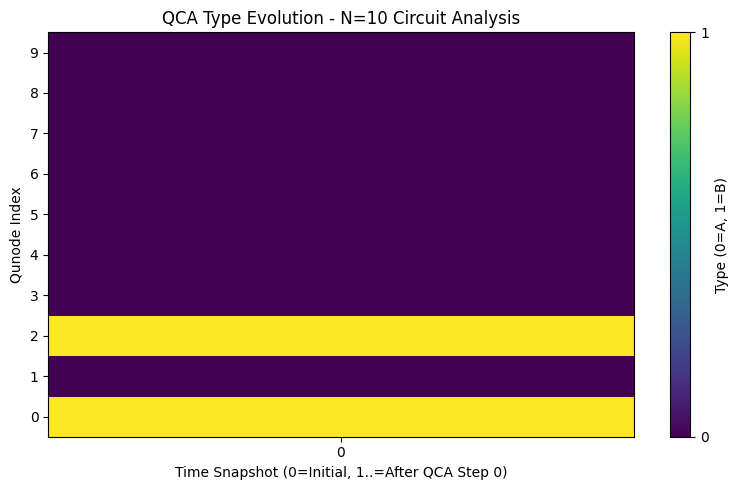



**************************************************************
**********           ANALYZING FOR N = 14           **********
**************************************************************

--- Analyzing Winning QCA Circuit for N = 14 ---
Initial Classical Types (N encoded in Q0-Q3): [1 1 1 0]
  p_reg (Q4-Q6) initial: [0 0 0]
  q_reg (Q7-Q9) initial: [0 0 0]

Statevector after Initial Preparation:
  Q4: P(|0>)=1.000, P(|1>)=0.000
  Q5: P(|0>)=1.000, P(|1>)=0.000
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|0>)=1.000, P(|1>)=0.000
  Q9: P(|0>)=1.000, P(|1>)=0.000
  Top 10 amplitudes (state | probability):
    |0000000111> : 1.0000 (amp: (1+0j))

Applying 8-gate Circuit Sequence:

Step 1: Applying RYY_PIO4 to qubits (3, 4)
  Q4: P(|0>)=0.854, P(|1>)=0.146
  Q5: P(|0>)=1.000, P(|1>)=0.000
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|0>)=1.000, P(|1>)=0.000
  Q9: P(|0>)=1.000, P(|1>)=0.000
  Top 10 amplitudes after RYY_PIO4(3, 4

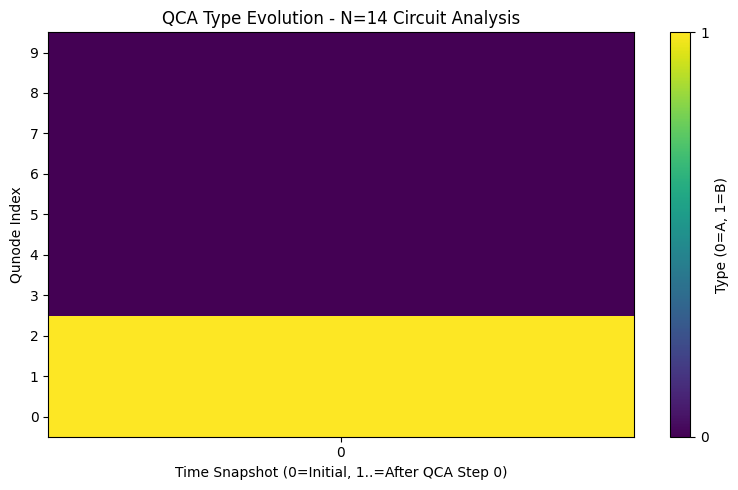



**************************************************************
**********           ANALYZING FOR N = 15           **********
**************************************************************

--- Analyzing Winning QCA Circuit for N = 15 ---
Initial Classical Types (N encoded in Q0-Q3): [1 1 1 1]
  p_reg (Q4-Q6) initial: [0 0 0]
  q_reg (Q7-Q9) initial: [0 0 0]

Statevector after Initial Preparation:
  Q4: P(|0>)=1.000, P(|1>)=0.000
  Q5: P(|0>)=1.000, P(|1>)=0.000
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|0>)=1.000, P(|1>)=0.000
  Q9: P(|0>)=1.000, P(|1>)=0.000
  Top 10 amplitudes (state | probability):
    |0000001111> : 1.0000 (amp: (1+0j))

Applying 8-gate Circuit Sequence:

Step 1: Applying RYY_PIO4 to qubits (3, 4)
  Q4: P(|0>)=0.854, P(|1>)=0.146
  Q5: P(|0>)=1.000, P(|1>)=0.000
  Q6: P(|0>)=1.000, P(|1>)=0.000
  Q7: P(|0>)=1.000, P(|1>)=0.000
  Q8: P(|0>)=1.000, P(|1>)=0.000
  Q9: P(|0>)=1.000, P(|1>)=0.000
  Top 10 amplitudes after RYY_PIO4(3, 4

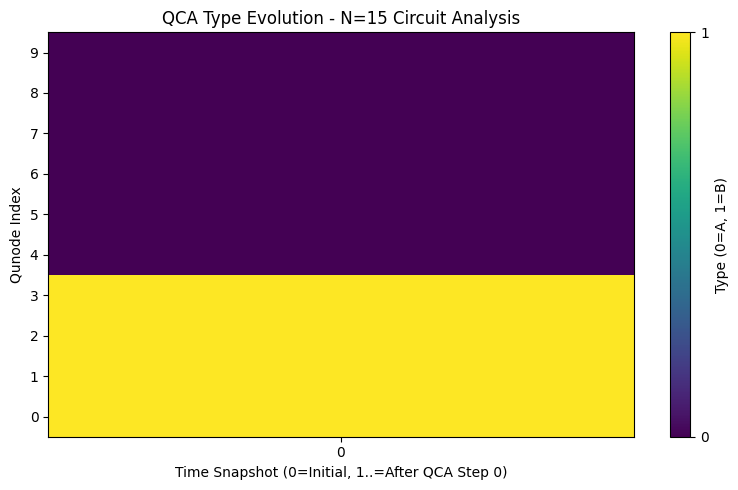

In [7]:

import numpy as np
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator # Correct import for AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city, plot_bloch_multivector, plot_histogram
from qiskit.circuit.library import CXGate, CZGate, RZZGate, RXXGate, RYYGate, SwapGate, HGate, XGate, IGate, SGate, TGate, CCXGate
import matplotlib.pyplot as plt
import time
import os
import json
from typing import List, Optional, Tuple, Dict, Any
import math

# --- QCA Parameters ---
TYPE_A = 0
TYPE_B = 1

# --- GATES Definition ---
GATES = {
    "H": HGate(), "X": XGate(), "I": IGate(), "S": SGate(), "T": TGate(),
    "CX": CXGate(), "CZ": CZGate(), "SWAP": SwapGate(), "CCX": CCXGate(),
    "RZZ_PIO4": RZZGate(np.pi/4), "RZZ_PIO2": RZZGate(np.pi/2),
    "RXX_PIO4": RXXGate(np.pi/4), "RYY_PIO4": RYYGate(np.pi/4),
}

# --- QuantumCellularAutomaton Class (Analysis Version) ---
class QuantumCellularAutomaton:
    def __init__(self, num_qunodes: int, initial_types: np.ndarray,
                 interaction_config: Dict,
                 type_update_rule_config: Dict,
                 initial_quantum_state_prep: str = "all_zero"
                ):
        self.num_qunodes = num_qunodes
        if len(initial_types) != num_qunodes: raise ValueError("initial_types length mismatch.")
        self.current_types = initial_types.copy()
        self.qca_quantum_state = None
        self.type_history = [self.current_types.copy()]
        self.quantum_outcome_history = []
        self.interaction_config = interaction_config
        self.type_update_rule_config = type_update_rule_config
        self.initial_quantum_state_prep = initial_quantum_state_prep
        self.full_interaction_circuit_for_viz = None

    def _get_gate_object(self, gate_name_or_obj):
        if isinstance(gate_name_or_obj, str): return GATES.get(gate_name_or_obj.upper(), GATES["I"])
        elif isinstance(gate_name_or_obj, qiskit.circuit.Instruction): return gate_name_or_obj
        return GATES["I"]

    def _prepare_initial_quantum_state(self) -> QuantumCircuit:
        qc_prep = QuantumCircuit(self.num_qunodes, name="InitialStatePrep")
        if self.initial_quantum_state_prep == "hadamard_all": [qc_prep.h(i) for i in range(self.num_qunodes)]
        elif self.initial_quantum_state_prep == "basis_from_type":
            for i in range(self.num_qunodes):
                if self.current_types[i] == TYPE_B: qc_prep.x(i)
        elif self.initial_quantum_state_prep == "mixed_A0_BH":
             for i in range(self.num_qunodes):
                if self.current_types[i] == TYPE_B: qc_prep.h(i)
        return qc_prep

    def initialize_statevector(self):
        prep_qc = self._prepare_initial_quantum_state()
        if prep_qc.num_qubits > 0:
            self.qca_quantum_state = Statevector(prep_qc)
        elif self.num_qunodes == 0 :
             self.qca_quantum_state = Statevector(np.array([1.+0.j]))
        else:
            self.qca_quantum_state = Statevector(QuantumCircuit(self.num_qunodes))

    def apply_gate_and_get_statevector(self, gate_spec, qubit_indices_spec) -> Optional[Statevector]:
        if self.qca_quantum_state is None:
            print("Error: QCA statevector not initialized. Call initialize_statevector() first.")
            return None

        op_to_apply = self._get_gate_object(gate_spec)
        if op_to_apply.name.lower() == 'id': return self.qca_quantum_state

        if not (isinstance(qubit_indices_spec, (list, tuple)) and \
                all(isinstance(idx, int) for idx in qubit_indices_spec) and \
                all(0 <= idx < self.num_qunodes for idx in qubit_indices_spec)):
            print(f"Warning: Invalid qubit indices '{qubit_indices_spec}' for gate {op_to_apply.name}. Skipping.")
            return self.qca_quantum_state

        qubit_indices = list(qubit_indices_spec)
        if len(set(qubit_indices)) != len(qubit_indices):
            print(f"Warning: Duplicate qubit indices in {qubit_indices} for gate {op_to_apply.name}. Skipping.")
            return self.qca_quantum_state
        if op_to_apply.num_qubits != len(qubit_indices):
            print(f"Warning: Gate {op_to_apply.name} (arity {op_to_apply.num_qubits}) incompatible with qubit list length {len(qubit_indices)}. Skipping.")
            return self.qca_quantum_state

        temp_qc = QuantumCircuit(self.num_qunodes)
        try:
            temp_qc.append(op_to_apply, qubit_indices)
            self.qca_quantum_state = self.qca_quantum_state.evolve(temp_qc)
            return self.qca_quantum_state
        except qiskit.exceptions.QiskitError as e:
            print(f"Error applying gate {op_to_apply.name} to {qubit_indices}: {e}")
            return self.qca_quantum_state

    def _build_full_interaction_circuit_for_step(self) -> QuantumCircuit:
        qc_full_step = self._prepare_initial_quantum_state()
        if self.num_qunodes > 0: qc_full_step.barrier(label="init_prep")
        interaction_applied_this_step = False
        if isinstance(self.interaction_config.get("circuit_sequence"), list):
            for op_spec_item in self.interaction_config["circuit_sequence"]:
                if isinstance(op_spec_item, tuple) and len(op_spec_item) == 2:
                    gate_s, q_indices_s = op_spec_item
                    if not (isinstance(q_indices_s, (list, tuple)) and \
                            all(isinstance(idx, int) for idx in q_indices_s) and \
                            all(0 <= idx < self.num_qunodes for idx in q_indices_s)): continue
                    q_indices = list(q_indices_s)
                    if len(set(q_indices)) != len(q_indices): continue
                    op = self._get_gate_object(gate_s)
                    if op.name.lower() != 'id':
                        if op.num_qubits != len(q_indices): continue
                        try: qc_full_step.append(op, q_indices); interaction_applied_this_step = True
                        except qiskit.exceptions.QiskitError: pass
        if interaction_applied_this_step and self.num_qunodes > 0: qc_full_step.barrier(label="interactions")
        self.full_interaction_circuit_for_viz = qc_full_step
        return qc_full_step

    def _apply_type_update_rule(self, quantum_outcomes_p1: np.ndarray) -> np.ndarray:
        new_types = self.current_types.copy(); rule_params = self.type_update_rule_config
        rule_name = rule_params.get("name", "direct_p1_to_type")
        if rule_name == "direct_p1_to_type":
            threshold = rule_params.get("p1_threshold_for_type_B", 0.5)
            for i in range(self.num_qunodes): new_types[i] = TYPE_B if quantum_outcomes_p1[i] > threshold else TYPE_A
        elif rule_name == "simple_threshold":
            thresh_A2B = rule_params.get("thresh_A_to_B", 0.55); thresh_B2A = rule_params.get("thresh_B_to_A", 0.45)
            for i in range(self.num_qunodes):
                my_p1 = quantum_outcomes_p1[i]
                if self.current_types[i] == TYPE_A and my_p1 > thresh_A2B: new_types[i] = TYPE_B
                elif self.current_types[i] == TYPE_B and my_p1 < thresh_B2A: new_types[i] = TYPE_A
        return new_types

    def run_one_step_for_analysis(self, verbose_level=0):
        full_qc = self._build_full_interaction_circuit_for_step()
        quantum_outcomes_p1 = np.zeros(self.num_qunodes)
        if full_qc.num_qubits > 0:
            try:
                final_sv = Statevector(full_qc)
                self.qca_quantum_state = final_sv
                for i in range(self.num_qunodes):
                    probs_qi = final_sv.probabilities([i])
                    quantum_outcomes_p1[i] = probs_qi[1] if len(probs_qi) == 2 else 0.0
            except qiskit.exceptions.QiskitError as e:
                print(f"Error during full step simulation for analysis: {e}. P1s set to 0.5.")
                quantum_outcomes_p1.fill(0.5)

        self.quantum_outcome_history.append(quantum_outcomes_p1.copy())
        new_types = self._apply_type_update_rule(quantum_outcomes_p1)

        if verbose_level >= 1:
            print(f"  Final P(|1⟩) after 1 circuit execution: {np.round(quantum_outcomes_p1, 3)}")
            print(f"  Derived Classical Types: {new_types}")
        return new_types, quantum_outcomes_p1

    def plot_type_evolution(self, title_suffix: str = "", experiment_label: str = ""):
        history_array = np.array(self.type_history)
        if history_array.size == 0 or self.num_qunodes == 0: print("No type history or qunodes to plot."); return
        num_snapshots = history_array.shape[0]
        fig_width = max(8, num_snapshots * 1.0); fig_height = max(4, self.num_qunodes * 0.5)
        plt.figure(figsize=(fig_width, fig_height))
        plt.imshow(history_array.T, cmap='viridis', aspect='auto', interpolation='nearest', origin='lower',
                   extent=[-0.5, num_snapshots - 1.5 if num_snapshots > 1 else 0.5 , -0.5, self.num_qunodes - 0.5])
        plt.xlabel(f"Time Snapshot (0=Initial, 1..=After QCA Step {num_snapshots-1 if num_snapshots > 1 else 0})"); plt.ylabel("Qunode Index")
        title = f"QCA Type Evolution"; plt.title(title + (f" - {experiment_label}" if experiment_label else "")+title_suffix, fontsize=12)
        plt.colorbar(label="Type (0=A, 1=B)", ticks=[TYPE_A, TYPE_B]);
        if self.num_qunodes > 0: plt.yticks(np.arange(self.num_qunodes))
        if num_snapshots > 0: plt.xticks(np.arange(num_snapshots))
        plt.tight_layout(); plt.show()

    def visualize_full_interaction_circuit(self):
        if self.full_interaction_circuit_for_viz and self.full_interaction_circuit_for_viz.num_qubits > 0:
            print("\n--- Full Interaction Circuit (One Step) Visualization ---")
            try:
                from IPython.display import display
                display(self.full_interaction_circuit_for_viz.draw(output='mpl', fold=-1, initial_state=True))
            except ImportError: print("IPython display not available. Text:\n", self.full_interaction_circuit_for_viz.draw(output='text', fold=-1))
            except Exception as e: print(f"MPL draw error: {e}. Text:\n{self.full_interaction_circuit_for_viz.draw(output='text', fold=-1)}")
        elif self.full_interaction_circuit_for_viz: print("Circuit has no qubits.")
        else: print("No full interaction circuit built or stored for visualization.")
# --- [END QCA CLASS] ---

# --- [is_prime_simple function] ---
def is_prime_simple(n: int) -> bool:
    if n < 2: return False
    if n == 2 or n == 3: return True
    if n % 2 == 0 or n % 3 == 0: return False
    i = 5; limit = int(math.sqrt(n))
    while i <= limit:
        if n % i == 0 or n % (i + 2) == 0: return False
        i += 6
    return True
# --- [END is_prime_simple] ---

# --- [analyze_winning_circuit function] ---
def analyze_winning_circuit(
    qca_rules: Dict,
    N_input: int,
    k_bits_N: int,
    k_bits_factor: int,
    show_statevector_probs_for_qubits: Optional[List[int]] = None,
    max_amplitudes_to_show: int = 8
):
    print(f"\n--- Analyzing Winning QCA Circuit for N = {N_input} ---")
    p_reg_start_idx = k_bits_N; p_reg_end_idx = k_bits_N + k_bits_factor
    q_reg_start_idx = p_reg_end_idx; q_reg_end_idx = q_reg_start_idx + k_bits_factor
    total_qca_qunodes = q_reg_end_idx
    initial_types = np.zeros(total_qca_qunodes, dtype=int)
    for i in range(k_bits_N):
        if (N_input >> (k_bits_N - 1 - i)) & 1: initial_types[i] = TYPE_B # MSB first encoding

    print(f"Initial Classical Types (N encoded in Q0-Q{k_bits_N-1}): {initial_types[:k_bits_N]}")
    print(f"  p_reg (Q{p_reg_start_idx}-Q{p_reg_end_idx-1}) initial: {initial_types[p_reg_start_idx:p_reg_end_idx]}")
    print(f"  q_reg (Q{q_reg_start_idx}-Q{q_reg_end_idx-1}) initial: {initial_types[q_reg_start_idx:q_reg_end_idx]}")

    qca = QuantumCellularAutomaton(
        num_qunodes=total_qca_qunodes, initial_types=initial_types,
        interaction_config=qca_rules["interaction_config"],
        type_update_rule_config=qca_rules["type_update_rule_config"],
        initial_quantum_state_prep=qca_rules.get("initial_quantum_state_prep", "hadamard_all")
    )

    qca.initialize_statevector()
    print("\nStatevector after Initial Preparation:")
    if qca.qca_quantum_state and qca.qca_quantum_state.num_qubits > 0:
        if show_statevector_probs_for_qubits:
            for q_idx in show_statevector_probs_for_qubits:
                if 0 <= q_idx < qca.num_qunodes:
                    probs = qca.qca_quantum_state.probabilities([q_idx])
                    print(f"  Q{q_idx}: P(|0>)={probs[0]:.3f}, P(|1>)={probs[1]:.3f}")
        sv_data = qca.qca_quantum_state.data; probs_data = np.abs(sv_data)**2
        sorted_indices = np.argsort(probs_data)[::-1]
        print(f"  Top {max_amplitudes_to_show} amplitudes (state | probability):")
        for i in range(min(max_amplitudes_to_show, len(sorted_indices))):
            idx = sorted_indices[i]
            if probs_data[idx] > 1e-6:
                 binary_state = format(idx, f'0{qca.num_qunodes}b')
                 print(f"    |{binary_state}> : {probs_data[idx]:.4f} (amp: {sv_data[idx]})")

    circuit_sequence = qca_rules.get("interaction_config", {}).get("circuit_sequence", [])
    print(f"\nApplying {len(circuit_sequence)}-gate Circuit Sequence:")

    for op_idx, op_spec in enumerate(circuit_sequence):
        if isinstance(op_spec, tuple) and len(op_spec) == 2:
            gate_s, q_indices_s = op_spec
            print(f"\nStep {op_idx + 1}: Applying {gate_s} to qubits {q_indices_s}")

            qca.apply_gate_and_get_statevector(gate_s, q_indices_s)

            if qca.qca_quantum_state:
                if show_statevector_probs_for_qubits:
                    for q_idx in show_statevector_probs_for_qubits:
                         if 0 <= q_idx < qca.num_qunodes:
                            probs = qca.qca_quantum_state.probabilities([q_idx]) # Use updated internal state
                            print(f"  Q{q_idx}: P(|0>)={probs[0]:.3f}, P(|1>)={probs[1]:.3f}")
                sv_data_trace = qca.qca_quantum_state.data; probs_data_trace = np.abs(sv_data_trace)**2
                sorted_indices_trace = np.argsort(probs_data_trace)[::-1]
                print(f"  Top {max_amplitudes_to_show} amplitudes after {gate_s}{q_indices_s}:")
                for i in range(min(max_amplitudes_to_show, len(sorted_indices_trace))):
                    idx_trace = sorted_indices_trace[i]
                    if probs_data_trace[idx_trace] > 1e-6:
                         binary_state_trace = format(idx_trace, f'0{qca.num_qunodes}b')
                         print(f"    |{binary_state_trace}> : {probs_data_trace[idx_trace]:.4f} (amp: {sv_data_trace[idx_trace]})")
            else: print(f"  Statevector became invalid after {gate_s}. Stopping trace."); break
        else: print(f"  Skipping invalid operation spec for trace: {op_spec}")

    qca.current_types = initial_types
    qca.type_history = [initial_types.copy()]
    qca.quantum_outcome_history = [] # Reset for this specific analysis run
    final_classical_types_after_circuit, final_quantum_outcomes_p1 = qca.run_one_step_for_analysis(verbose_level=0)

    p_pred_binary = final_classical_types_after_circuit[p_reg_start_idx : p_reg_end_idx]
    q_pred_binary = final_classical_types_after_circuit[q_reg_start_idx : q_reg_end_idx]
    p_pred = 0; q_pred = 0
    for bit_type in p_pred_binary: p_pred = (p_pred << 1) | (1 if bit_type == TYPE_B else 0)
    for bit_type in q_pred_binary: q_pred = (q_pred << 1) | (1 if bit_type == TYPE_B else 0)

    print("\n--- Final State after Full Circuit Execution and Type Update (from QCA perspective) ---")
    print(f"Final P(|1⟩) values from QCA step: {np.round(final_quantum_outcomes_p1, 3)}")
    print(f"Final Classical Types from QCA step: {final_classical_types_after_circuit}")
    print(f"  p_reg: {p_pred_binary}, Decoded p_pred: {p_pred}")
    print(f"  q_reg: {q_pred_binary}, Decoded q_pred: {q_pred}")
    print(f"Product p_pred * q_pred = {p_pred * q_pred} (Expected N = {N_input})")

    qca._build_full_interaction_circuit_for_step()
    qca.visualize_full_interaction_circuit()
    qca.plot_type_evolution(experiment_label=f"N={N_input} Circuit Analysis")
# --- [END analyze_winning_circuit] ---

# --- Main Section to Analyze the NEW Best Evolved Algorithm ---
if __name__ == "__main__":
    print("--- Analyzing NEW Best Evolved QCA Factorization Algorithm (from Gen ~50, Fitness 353.3779) ---")

    # --- THE NEW BEST QCA RULES (Fitness 353.3779) ---
    new_best_evolved_qca_rules = {
      "interaction_config": {
        "circuit_sequence": [
          ("RYY_PIO4", (3, 4)),
          ("CX", (0, 6)),
          ("CCX", (9, 2, 4)),
          ("X", (3,)),
          ("RYY_PIO4", (2, 1)),
          ("RYY_PIO4", (6, 0)),
          ("RXX_PIO4", (2, 8)),
          ("CCX", (1, 6, 9))
        ]
      },
      "type_update_rule_config": {
        "name": "simple_threshold", # Note: This rule uses memory of current_types
        "thresh_A_to_B": 0.31695097613634415,
        "thresh_B_to_A": 0.15302094754762774
      },
      "initial_quantum_state_prep": "basis_from_type"
    }

    # Factorization Problem Parameters
    K_BITS_N_ENCODING = 4
    K_BITS_FACTOR_DECODING = 3 # p,q up to 7

    p_indices = list(range(K_BITS_N_ENCODING, K_BITS_N_ENCODING + K_BITS_FACTOR_DECODING))
    q_indices = list(range(K_BITS_N_ENCODING + K_BITS_FACTOR_DECODING, K_BITS_N_ENCODING + 2 * K_BITS_FACTOR_DECODING))
    output_qubit_indices_to_watch = p_indices + q_indices

    # --- Analyze for N=10 ---
    print("\n\n**************************************************************")
    print("**********           ANALYZING FOR N = 10           **********")
    print("**************************************************************")
    analyze_winning_circuit(
        new_best_evolved_qca_rules,
        N_input=10, # Expected factors: 2, 5
        k_bits_N=K_BITS_N_ENCODING,
        k_bits_factor=K_BITS_FACTOR_DECODING,
        show_statevector_probs_for_qubits = output_qubit_indices_to_watch,
        max_amplitudes_to_show=10
    )

    # --- Analyze for N=14 ---
    print("\n\n**************************************************************")
    print("**********           ANALYZING FOR N = 14           **********")
    print("**************************************************************")
    analyze_winning_circuit(
        new_best_evolved_qca_rules,
        N_input=14, # Expected factors: 2, 7. GA output for this rule: p=7, q=2
        k_bits_N=K_BITS_N_ENCODING,
        k_bits_factor=K_BITS_FACTOR_DECODING,
        show_statevector_probs_for_qubits = output_qubit_indices_to_watch,
        max_amplitudes_to_show=10
    )

    # --- Analyze for N=15 (where it previously regressed) ---
    print("\n\n**************************************************************")
    print("**********           ANALYZING FOR N = 15           **********")
    print("**************************************************************")
    analyze_winning_circuit(
        new_best_evolved_qca_rules,
        N_input=15, # Expected factors: 3, 5. GA output for this rule: p=7, q=2
        k_bits_N=K_BITS_N_ENCODING,
        k_bits_factor=K_BITS_FACTOR_DECODING,
        show_statevector_probs_for_qubits = output_qubit_indices_to_watch,
        max_amplitudes_to_show=10
    )